<a href="https://colab.research.google.com/github/edilsonchaves/MVP-Analise-de-Dados-Oscar-Research/blob/main/OscarResearch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Descrição do Tabalho**

Neste trabalho busca fazer um levantamento sobre a maior premiação do oscar desde a sua primeira edição que ocorreu no ano de 1929 referente a filmes lançados nos anos de 1927/1928 até a edição de numero 97 que ocorreu no ano de 2024.
<br><br>

# **Coleta de dados**

Os dados foram coletaods na plataforma kaggle no link : https://www.kaggle.com/datasets/unanimad/the-oscar-award e os dados brutos foram armazenados neste repositório git




# **Dados Brutos**

Na tabela subsequente é mostrado os dados brutos obtidos através do site com um total de 12014 entradas e 16 colunas.

In [1]:
import requests
import pandas as pd
url = "https://raw.githubusercontent.com/edilsonchaves/MVP-Analise-de-Dados-Oscar-Research/refs/heads/main/oscar_full_data.csv"
df = pd.read_csv(url, sep="\t")
display(df)

,Ceremony,Year,Class,CanonicalCategory,Category,NomId,Film,FilmId,Name,Nominees,NomineeIds,Winner,Detail,Note,Citation,MultifilmNomination
0,1,1927/28,Acting,ACTOR IN A LEADING ROLE,ACTOR,an0051251,The Noose,tt0019217,Richard Barthelmess,Richard Barthelmess,nm0001932,NaN,Nickie Elkins,NaN,NaN,True
1,1,1927/28,Acting,ACTOR IN A LEADING ROLE,ACTOR,an0051252,The Patent Leather Kid,tt0018253,Richard Barthelmess,Richard Barthelmess,nm0001932,NaN,The Patent Leather Kid,NaN,NaN,True
2,1,1927/28,Acting,ACTOR IN A LEADING ROLE,ACTOR,an0051250a,The Last Command,tt0019071,Emil Jannings,Emil Jannings,nm0417837,True,General Dolgorucki [Grand Duke Sergius Alexander],NaN,NaN,True
3,1,1927/28,Acting,ACTOR IN A LEADING ROLE,ACTOR,an0051250b,The Way of All Flesh,tt0019553,Emil Jannings,Emil Jannings,nm0417837,True,August Schilling,NaN,NaN,True
4,1,1927/28,Acting,ACTRESS IN A LEADING ROLE,ACTRESS,an0051255,A Ship Comes In,tt0018389,Louise Dresser,Louise Dresser,nm0237571,NaN,Mrs. Pleznik,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12009,97,2024,SciTech,SCIENTIFIC AND TECHNICAL AWARD (Technical Achi...,SCIENTIFIC AND TECHNICAL AWARD (Technical Achi...,NaN,NaN,NaN,NaN,"Dustin Brooks, Colin Decker",NaN,True,NaN,Fire for Hire's gel first publicly demonstrate...,To DUSTIN BROOKS and COLIN DECKER for the deve...,NaN
12010,97,2024,SciTech,SCIENTIFIC AND TECHNICAL AWARD (Technical Achi...,SCIENTIFIC AND TECHNICAL AWARD (Technical Achi...,NaN,NaN,NaN,NaN,"Attila T. Áfra, Timo Aila",NaN,True,NaN,Open Image Denoise is an open-source library t...,To ATTILA T. ÁFRA for the creation of Intel Op...,NaN
12011,97,2024,SciTech,SCIENTIFIC AND TECHNICAL AWARD (Technical Achi...,SCIENTIFIC AND TECHNICAL AWARD (Technical Achi...,NaN,NaN,NaN,NaN,Mark Noel,NaN,True,NaN,The NACMO series of modular motion bases enabl...,To MARK NOEL for adapting and enhancing the sa...,NaN
12012,97,2024,SciTech,SCIENTIFIC AND TECHNICAL AWARD (Technical Achi...,SCIENTIFIC AND TECHNICAL AWARD (Technical Achi...,NaN,NaN,NaN,NaN,"Su Tie, Bei Shimen, Zhao Yanchong",NaN,True,NaN,Utilizing three-axis stabilization through mul...,To SU TIE for the development of the sensor an...,NaN


# **Pré Processamento**

Antes de inicializar as análises dos dados algumas modificação foram necessárias de serem realizadas para melhorar a qualidade dos dados

## Pré processamento Data Frame
A primeira etapa de pré processamento dos dados foi avaliar quais as colunas existentes na tabela para posteriormente poder escolher aquelas que mais poderiam ajudar nas respostas das questões. Por isso que das dezesseis colunas existentes apenas sete foram escolhidas sendo elas as

* Ceremony
* Year
* Canonical Category
* Film
* Name
* Nominees
* Winner
<br>
Além destas colunas foi necessário acrescentar mais 3 colunas

* Genre: Genero do Filme que foi Indicado ao oscar
* Birth Country: País de nascimento nos casos de categorias do oscar que homenageiam pessoas
* Birth Continent: Continente de nascimento nos casos de categorias do oscar que homenageiam pessoas

Na coluna de vencedores para facilitar a leitura foi preenchido as tabelas vazias com a string de False no valor.

In [2]:
df.insert(8, "Genre", "Genre of Film")
df.insert(10, "Birth Country", "Null")
df.insert(11, "Birth Continent", "Null")

In [3]:
df_Selected_Colluns = ["Ceremony", "Year", "CanonicalCategory", "Film", "Genre", "Name", "Nominees", "Birth Country", "Birth Continent", "Winner"]
df_With_Colluns = df[df_Selected_Colluns].copy()

In [4]:
df_With_Colluns["Winner"] = df_With_Colluns["Winner"].fillna("False")

In [5]:
display(df_With_Colluns)

,Ceremony,Year,CanonicalCategory,Film,Genre,Name,Nominees,Birth Country,Birth Continent,Winner
0,1,1927/28,ACTOR IN A LEADING ROLE,The Noose,Genre of Film,Richard Barthelmess,Richard Barthelmess,Null,Null,False
1,1,1927/28,ACTOR IN A LEADING ROLE,The Patent Leather Kid,Genre of Film,Richard Barthelmess,Richard Barthelmess,Null,Null,False
2,1,1927/28,ACTOR IN A LEADING ROLE,The Last Command,Genre of Film,Emil Jannings,Emil Jannings,Null,Null,True
3,1,1927/28,ACTOR IN A LEADING ROLE,The Way of All Flesh,Genre of Film,Emil Jannings,Emil Jannings,Null,Null,True
4,1,1927/28,ACTRESS IN A LEADING ROLE,A Ship Comes In,Genre of Film,Louise Dresser,Louise Dresser,Null,Null,False
...,...,...,...,...,...,...,...,...,...,...
12009,97,2024,SCIENTIFIC AND TECHNICAL AWARD (Technical Achi...,NaN,Genre of Film,NaN,"Dustin Brooks, Colin Decker",Null,Null,True
12010,97,2024,SCIENTIFIC AND TECHNICAL AWARD (Technical Achi...,NaN,Genre of Film,NaN,"Attila T. Áfra, Timo Aila",Null,Null,True
12011,97,2024,SCIENTIFIC AND TECHNICAL AWARD (Technical Achi...,NaN,Genre of Film,NaN,Mark Noel,Null,Null,True
12012,97,2024,SCIENTIFIC AND TECHNICAL AWARD (Technical Achi...,NaN,Genre of Film,NaN,"Su Tie, Bei Shimen, Zhao Yanchong",Null,Null,True


## **Pré Processamento dos Dados**

Posteriormente que foi trabalhado consistiu em avaliar quais as Categorias de premiação do Oscar seriam trabalhadas para isso foram escolhidas 4 categorias no contexto de filmes sendo estas

* Melhor Filme
* Melhor Filme Internacional
* Melhor Animação (subdividido em Longo e Curto)

Além de quatro no contexto de premiações para pessoas que foram

* Melhor Ator Principal (Subdividido em Ator e Atriz)
* Melhor Ator Coadjuvante (Subdividido em Ator e Atriz)
* Melhor Direção
* Melhor Roteiro (Adaptado, Original)

In [6]:
df_Selected_Categorys = ["BEST PICTURE",
                          "INTERNATIONAL FEATURE FILM",
                          "DIRECTING",
                          "ACTOR IN A LEADING ROLE",
                          "ACTRESS IN A LEADING ROLE",
                          "ACTOR IN A SUPPORTING ROLE",
                          "ACTRESS IN A SUPPORTING ROLE",
                          "ANIMATED FEATURE FILM",
                          "SHORT FILM (Animated)",
                          "WRITING (Adapted Screenplay)",
                          "WRITING (Original Story)",
                          ]
df_Category_Research = df_With_Colluns[df_With_Colluns["CanonicalCategory"].isin(df_Selected_Categorys)]

## Resultado
Tais pre processamentos reduziu a amostragem para 4403 entradas e 10 colunas como mostrado no diplay abaixo

In [7]:
display(df_Category_Research)

,Ceremony,Year,CanonicalCategory,Film,Genre,Name,Nominees,Birth Country,Birth Continent,Winner
0,1,1927/28,ACTOR IN A LEADING ROLE,The Noose,Genre of Film,Richard Barthelmess,Richard Barthelmess,Null,Null,False
1,1,1927/28,ACTOR IN A LEADING ROLE,The Patent Leather Kid,Genre of Film,Richard Barthelmess,Richard Barthelmess,Null,Null,False
2,1,1927/28,ACTOR IN A LEADING ROLE,The Last Command,Genre of Film,Emil Jannings,Emil Jannings,Null,Null,True
3,1,1927/28,ACTOR IN A LEADING ROLE,The Way of All Flesh,Genre of Film,Emil Jannings,Emil Jannings,Null,Null,True
4,1,1927/28,ACTRESS IN A LEADING ROLE,A Ship Comes In,Genre of Film,Louise Dresser,Louise Dresser,Null,Null,False
...,...,...,...,...,...,...,...,...,...,...
11986,97,2024,WRITING (Adapted Screenplay),A Complete Unknown,Genre of Film,Screenplay by James Mangold and Jay Cocks,"James Mangold, Jay Cocks",Null,Null,False
11987,97,2024,WRITING (Adapted Screenplay),Conclave,Genre of Film,Screenplay by Peter Straughan,Peter Straughan,Null,Null,True
11988,97,2024,WRITING (Adapted Screenplay),Emilia Pérez,Genre of Film,Screenplay by Jacques Audiard; In collaboratio...,"Jacques Audiard, In collaboration with Thomas ...",Null,Null,False
11989,97,2024,WRITING (Adapted Screenplay),Nickel Boys,Genre of Film,Screenplay by RaMell Ross & Joslyn Barnes,"RaMell Ross, Joslyn Barnes",Null,Null,False


## Obtenção dos Dados

Para preencher os dados das novas colunas adicionadas foram realizadas duas consultas separadas via API no site The Movie Database ([TMDB](https://https://www.themoviedb.org/?language=pt-BR)) um site com um grande data set com informações no universo cinematográfico.

Tais consultas permitiram obter data frames que posteriormente foram utilizados para preencher a maior parte dos dados necessitando apenas algumas poucas dezenas realizar o preenchimento manual

In [8]:
import requests
import pandas as pd

API_KEY = "Personal_Key"

# Função para buscar filme na API
def buscar_filme_tmdb(nome, ano):
    url = "https://api.themoviedb.org/3/search/movie"
    partes = ano.split('/')
    if(len(partes) >= 2):
      ano = partes[0]
    else:
      ano = partes[0]

    params = {"api_key": API_KEY, "query": nome, "year": ano, "language": "en-US"}
    r = requests.get(url, params=params).json()
    if r["results"]:
        filme = r["results"][0]
        filme_id = filme["id"]
        titulo = filme["title"]
        ano_filme = filme["release_date"][:4] if filme.get("release_date") else ano
        detalhes = requests.get(f"https://api.themoviedb.org/3/movie/{filme_id}", params={"api_key": API_KEY, "language": "en-US"}).json()
        generos = [g['name'] for g in detalhes.get("genres", [])]
        return titulo, ano_filme, generos
    return None, None, None

In [9]:
import time
import os

def ListarGenerosFilme(df, fileName):
  caminho_csv = f"{fileName}.csv"

  # SE O ARQUIVO JÁ EXISTIR → ENCERRA O MÉTODO
  if os.path.exists(caminho_csv):
      print("Arquivo já existe. Processo cancelado.")
      return

  print("Arquivo não encontrado. Iniciando geração do dataset...")

  # Lista de filmes e anos
  df_unique = df[["Year","Film"]].drop_duplicates()
  dados_tmdb = []
  count = 0
  for _, row in df_unique.iterrows():
      print(row["Film"], " ", count)
      count += 1
      years = row["Year"].split("/")
      if(len(years) == 2):
        titulo, ano, generos = buscar_filme_tmdb(row["Film"], years[0])
        if(generos is None):
          year = years[0][:2] + years[1]
          titulo, ano, generos = buscar_filme_tmdb(row["Film"], year)
      else:
        titulo, ano, generos = buscar_filme_tmdb(row["Film"], years[0])

      print("_________________________________________________________________________________________")

      if generos:
        genero_principal = generos[0]
      else:
        genero_principal = "Genre of Film"

      dados_tmdb.append({
          "Film": titulo if titulo else row["Film"],
          "Year": ano if ano else row["Year"],
          "Genre": genero_principal
      })
      time.sleep(0.3)

  df_tmdb = pd.DataFrame(dados_tmdb)

  # Exibir resultado final
  print(df_tmdb)
  # Salvar CSV
  df_tmdb.to_csv(f"{fileName}.csv", index=False, encoding='utf-8-sig')

In [10]:
def pais_nascimento_ator(nome_ator):

    url_search = "https://api.themoviedb.org/3/search/person"

    params = {
        "api_key": API_KEY,
        "query": nome_ator
    }

    r = requests.get(url_search, params=params, timeout=10)
    data = r.json()

    if not data["results"]:
        return None

    person_id = data["results"][0]["id"]

    url_details = f"https://api.themoviedb.org/3/person/{person_id}"

    r = requests.get(url_details, params={"api_key": API_KEY}, timeout=10)
    data = r.json()

    place = data.get("place_of_birth")
    print(nome_ator)

    if not place:
      return None

    return place.split(",")[-1].strip()

In [11]:
import time
def ListarPaisPessoas(df, fileName):
  caminho_csv = f"{fileName}.csv"

  # SE O ARQUIVO JÁ EXISTIR → ENCERRA O MÉTODO
  if os.path.exists(caminho_csv):
      print("Arquivo já existe. Processo cancelado.")
      return

  print("Arquivo não encontrado. Iniciando geração do dataset...")

  # Lista de filmes e anos
  df_unique = df[["Nominees", "Birth Country"]].drop_duplicates()
  dados_tmdb = []
  count = 0
  for _, row in df_unique.iterrows():
      count += 1
      NomineesHumans = row["Nominees"].split(",")
      paises = []
      for human in NomineesHumans:
        human = human.strip()
        pais_result = pais_nascimento_ator(human)
        paises.append(pais_result)

      dados_tmdb.append({
          "Nominess": row["Nominees"],
          "Birth Country": paises
      })
      time.sleep(0.3)

  df_tmdb = pd.DataFrame(dados_tmdb)
  df_tmdb.to_csv(f"{fileName}.csv", index=False, encoding='utf-8-sig')


Após da criação desses datasets os dados foram colocados no git hub e podem ser vistos abaixo

In [12]:
url_genre = "https://raw.githubusercontent.com/edilsonchaves/MVP-Analise-de-Dados-Oscar-Research/refs/heads/main/all_film_genre_tmdb.csv"

df_films_genre = pd.read_csv(url_genre, sep = ",")

display(df_films_genre)

,Film,Year,Genre
0,The Noose,1928,Drama
1,The Patent Leather Kid,1927,War
2,The Last Command,1928,Drama
3,The Way of All Flesh,1927,Drama
4,A Ship Comes In,1928,Drama
...,...,...,...
2405,Yuck!,2024,Animation
2406,The Girl with the Needle,2024,Drama
2407,The Seed of the Sacred Fig,2024,Drama
2408,Dune: Part Two,2024,Science Fiction


In [13]:
url_human_data = "https://raw.githubusercontent.com/edilsonchaves/MVP-Analise-de-Dados-Oscar-Research/refs/heads/main/human_film_tmdb.csv"

df_human_data = pd.read_csv(url_human_data, sep = ",")

display(df_human_data)

,Nominess,Birth Country
0,Richard Barthelmess,['USA']
1,Emil Jannings,['Switzerland']
2,Louise Dresser,['USA']
3,Janet Gaynor,['USA']
4,Gloria Swanson,['USA']
...,...,...
1714,"James Mangold, Jay Cocks","['USA', 'USA']"
1715,Peter Straughan,['UK']
1716,"Jacques Audiard, In collaboration with Thomas ...","['France', 'France', 'France', 'France']"
1717,"RaMell Ross, Joslyn Barnes","['Germany', 'USA']"


Com os dados obtidos é usado estas duas tabelas para atualizar os dados da tabela principal

In [14]:
map_genero = dict(zip(df_films_genre["Film"], df_films_genre["Genre"]))
df_Genres = df_Category_Research.copy()
df_Genres["Genre"] = df_Genres["Film"].map(map_genero)
display(df_Genres)

,Ceremony,Year,CanonicalCategory,Film,Genre,Name,Nominees,Birth Country,Birth Continent,Winner
0,1,1927/28,ACTOR IN A LEADING ROLE,The Noose,Drama,Richard Barthelmess,Richard Barthelmess,Null,Null,False
1,1,1927/28,ACTOR IN A LEADING ROLE,The Patent Leather Kid,War,Richard Barthelmess,Richard Barthelmess,Null,Null,False
2,1,1927/28,ACTOR IN A LEADING ROLE,The Last Command,Drama,Emil Jannings,Emil Jannings,Null,Null,True
3,1,1927/28,ACTOR IN A LEADING ROLE,The Way of All Flesh,Drama,Emil Jannings,Emil Jannings,Null,Null,True
4,1,1927/28,ACTRESS IN A LEADING ROLE,A Ship Comes In,Drama,Louise Dresser,Louise Dresser,Null,Null,False
...,...,...,...,...,...,...,...,...,...,...
11986,97,2024,WRITING (Adapted Screenplay),A Complete Unknown,Drama,Screenplay by James Mangold and Jay Cocks,"James Mangold, Jay Cocks",Null,Null,False
11987,97,2024,WRITING (Adapted Screenplay),Conclave,Drama,Screenplay by Peter Straughan,Peter Straughan,Null,Null,True
11988,97,2024,WRITING (Adapted Screenplay),Emilia Pérez,Drama,Screenplay by Jacques Audiard; In collaboratio...,"Jacques Audiard, In collaboration with Thomas ...",Null,Null,False
11989,97,2024,WRITING (Adapted Screenplay),Nickel Boys,Drama,Screenplay by RaMell Ross & Joslyn Barnes,"RaMell Ross, Joslyn Barnes",Null,Null,False


In [15]:
map_BirthCountry = dict(zip(df_human_data["Nominess"], df_human_data["Birth Country"]))
df_BirthCountry = df_Genres.copy()
df_BirthCountry["Birth Country"] = df_BirthCountry["Nominees"].map(map_BirthCountry)

display(df_BirthCountry)

,Ceremony,Year,CanonicalCategory,Film,Genre,Name,Nominees,Birth Country,Birth Continent,Winner
0,1,1927/28,ACTOR IN A LEADING ROLE,The Noose,Drama,Richard Barthelmess,Richard Barthelmess,['USA'],Null,False
1,1,1927/28,ACTOR IN A LEADING ROLE,The Patent Leather Kid,War,Richard Barthelmess,Richard Barthelmess,['USA'],Null,False
2,1,1927/28,ACTOR IN A LEADING ROLE,The Last Command,Drama,Emil Jannings,Emil Jannings,['Switzerland'],Null,True
3,1,1927/28,ACTOR IN A LEADING ROLE,The Way of All Flesh,Drama,Emil Jannings,Emil Jannings,['Switzerland'],Null,True
4,1,1927/28,ACTRESS IN A LEADING ROLE,A Ship Comes In,Drama,Louise Dresser,Louise Dresser,['USA'],Null,False
...,...,...,...,...,...,...,...,...,...,...
11986,97,2024,WRITING (Adapted Screenplay),A Complete Unknown,Drama,Screenplay by James Mangold and Jay Cocks,"James Mangold, Jay Cocks","['USA', 'USA']",Null,False
11987,97,2024,WRITING (Adapted Screenplay),Conclave,Drama,Screenplay by Peter Straughan,Peter Straughan,['UK'],Null,True
11988,97,2024,WRITING (Adapted Screenplay),Emilia Pérez,Drama,Screenplay by Jacques Audiard; In collaboratio...,"Jacques Audiard, In collaboration with Thomas ...","['France', 'France', 'France', 'France']",Null,False
11989,97,2024,WRITING (Adapted Screenplay),Nickel Boys,Drama,Screenplay by RaMell Ross & Joslyn Barnes,"RaMell Ross, Joslyn Barnes","['Germany', 'USA']",Null,False


Para os filmes internacionais foi preciso adicionar via código a informação de alguns filmes para saber sua localização

In [16]:
df_BirthCountry.loc[df_BirthCountry["Film"] == "The Walls of Malapaga", "Name"] = "Italy"
df_BirthCountry.loc[df_BirthCountry["Film"] == "Rashomon", "Name"] = "Japan"
df_BirthCountry.loc[df_BirthCountry["Film"] == "Forbidden Games", "Name"] = "France"
df_BirthCountry.loc[df_BirthCountry["Film"] == "Gate of Hell", "Name"] = "Japan"
df_BirthCountry.loc[df_BirthCountry["Film"] == "Samurai, The Legend of Musashi", "Name"] = "Japan"

Finalizando tendo todos os países que foram premiados foi só subdivi-los de acordo com seu continente obtendo assim a versão oficialdo data frame que será utilizado para as analises de dado

In [17]:
country_continent = {
    "USA": "North America",
    "Canada": "North America",
    "Mexico": "Central America",
    "Puerto Rico": "Central America",
    "Cuba": "Central America",
    "Brazil": "South America",
    "Argentina": "South America",
    "Colombia": "South America",
    "UK": "Europe",
    "U.K.": "Europe",
    "Scotland": "Europe",
    "Ireland": "Europe",
    "Republic of Ireland": "Europe",
    "France": "Europe",
    "Germany": "Europe",
    "Austria": "Europe",
    "Hungary": "Europe",
    "Poland": "Europe",
    "Romania": "Europe",
    "Ukraine": "Europe",
    "Sweden": "Europe",
    "Switzerland": "Europe",
    "Denmark": "Europe",
    "Belgium": "Europe",
    "Netherlands": "Europe",
    "Portugal": "Europe",
    "Spain": "Europe",
    "Greece": "Europe",
    "Italy": "Europe",
    "Norway": "Europe",
    "Latvia": "Europe",
    "Lithuania": "Europe",
    "Czech Republic": "Europe",
    "Republic of Georgia": "Europe",
    "Austria-Hungary": "Europe",
    "Russian Empire": "Europe",
    "Russia": "Europe",
    "Moldova": "Europe",
    "South Africa": "Africa",
    "South African Republic": "Africa",
    "Egypt": "Africa",
    "Kenya": "Africa",
    "Uganda": "Africa",
    "Somalia": "Africa",
    "Ethiopia": "Africa",
    "Benin": "Africa",
    "Eswatini": "Africa",
    "China": "Asia",
    "Japan": "Asia",
    "India": "Asia",
    "Iran": "Asia",
    "Israel": "Asia",
    "Turkey": "Asia",
    "Taiwan": "Asia",
    "South Korea": "Asia",
    "Korea": "Asia",
    "Vietnam": "Asia",
    "Malaysia": "Asia",
    "Thailand": "Asia",
    "Cambodia": "Asia",
    "Cyprus": "Asia",
    "Georgia": "Asia",
    "Australia": "Oceania",
    "New Zealand": "Oceania",
    "French Polynesia": "Oceania"
}

In [18]:
import re

df_Official = df_BirthCountry.copy()

df_Official["Birth Country"] = df_Official["Birth Country"].apply(
    lambda x: re.findall(r"'([^']+)'", str(x)) if pd.notna(x) else []
)

df_Official["Birth Continent"] = df_Official["Birth Country"].apply(
    lambda countries: [country_continent.get(c) for c in countries] if isinstance(countries, list) else []
)

display(df_Official)

,Ceremony,Year,CanonicalCategory,Film,Genre,Name,Nominees,Birth Country,Birth Continent,Winner
0,1,1927/28,ACTOR IN A LEADING ROLE,The Noose,Drama,Richard Barthelmess,Richard Barthelmess,[USA],[North America],False
1,1,1927/28,ACTOR IN A LEADING ROLE,The Patent Leather Kid,War,Richard Barthelmess,Richard Barthelmess,[USA],[North America],False
2,1,1927/28,ACTOR IN A LEADING ROLE,The Last Command,Drama,Emil Jannings,Emil Jannings,[Switzerland],[Europe],True
3,1,1927/28,ACTOR IN A LEADING ROLE,The Way of All Flesh,Drama,Emil Jannings,Emil Jannings,[Switzerland],[Europe],True
4,1,1927/28,ACTRESS IN A LEADING ROLE,A Ship Comes In,Drama,Louise Dresser,Louise Dresser,[USA],[North America],False
...,...,...,...,...,...,...,...,...,...,...
11986,97,2024,WRITING (Adapted Screenplay),A Complete Unknown,Drama,Screenplay by James Mangold and Jay Cocks,"James Mangold, Jay Cocks","[USA, USA]","[North America, North America]",False
11987,97,2024,WRITING (Adapted Screenplay),Conclave,Drama,Screenplay by Peter Straughan,Peter Straughan,[UK],[Europe],True
11988,97,2024,WRITING (Adapted Screenplay),Emilia Pérez,Drama,Screenplay by Jacques Audiard; In collaboratio...,"Jacques Audiard, In collaboration with Thomas ...","[France, France, France, France]","[Europe, Europe, Europe, Europe]",False
11989,97,2024,WRITING (Adapted Screenplay),Nickel Boys,Drama,Screenplay by RaMell Ross & Joslyn Barnes,"RaMell Ross, Joslyn Barnes","[Germany, USA]","[Europe, North America]",False


# Analise de dados

##Métodos Auxiliares

In [19]:
def DataFrameInfoTotalCount(df, collum):
  return df[collum].value_counts().to_frame()

In [20]:
def DataFrameInfoPercentual(df, collum):
  percentuais = (
    df[collum]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
  )
  percentuais.columns = [collum, "Percentual"]
  return percentuais

In [21]:
def last_show_information(df, collum):
  df_official_copy = df_Official.copy()

  df_Info = pd.DataFrame(df[collum].unique(), columns=[collum])
  ultimo_ano = df.groupby(collum)["Year"].max().reset_index()
  ultimo_ano.columns = [collum, "LastYear"]

  primeiro_ano = str(df["Year"].min()).split('/')[0]
  ano_atual = str(df_official_copy["Year"].max()).split('/')[0]

  ultimo_ano["YearsWithout"] = int(ano_atual) - ultimo_ano["LastYear"].astype(str).str.split('/').str[0].astype(int)

  df_Info = df_Info.merge(ultimo_ano, on=collum, how="left")

  df_Info.loc[df_Info["LastYear"].isna(), "LastYear"] = -1
  df_Info.loc[df_Info["YearsWithout"].isna(), "YearsWithout"] = int(ano_atual) - int(primeiro_ano)

  display(df_Info)

In [22]:
import math

def floor_2(x):
    return math.floor(x * 100) / 100

def calculate_basics_analitics(df, collum):
  data_analytics = df.groupby(collum)['Count'].agg(
      Média=lambda x: floor_2(x.mean()),
      Mediana='median',
      Moda=lambda x: x.mode().tolist(),
      Amplitude = lambda x: x.max() - x.min(),
      Desvio = lambda x: x.std()
  ).reset_index()
  return data_analytics

In [23]:
def show_raw_data_count_for_year(df, collum):
  df_count = (
    df.groupby(["Year", collum])
    .size()
    .unstack(fill_value=0)
    .stack()
    .reset_index(name="Count")
  )
  return df_count

In [24]:
import numpy as np
import matplotlib.pyplot as plt

def PizzaTopN(df, top_n=5):

    df_sorted = df.sort_values(df.columns[1], ascending=False)

    top = df_sorted.head(top_n)

    others = df_sorted.iloc[top_n:, 1].sum()

    labels = top.iloc[:,0].tolist()
    values = top.iloc[:,1].tolist()

    if others > 0:
        labels.append("Outros")
        values.append(others)

    colors = plt.cm.tab20(np.linspace(0,1,len(values)))

    plt.figure(figsize=(8,8))

    plt.pie(
        values,
        labels=labels,
        autopct='%1.2f%%',
        startangle=90,
        colors=colors
    )

    plt.axis('equal')
    plt.show()

In [25]:
import matplotlib.pyplot as plt

def BoxplotByCollumForYears(df, column):

  result = (
        df.groupby(['Year', column])
        .size()
        .reset_index(name='Indicacoes')
    )

  years = df['Year'].unique()
  values = df[column].unique()
  idx = pd.MultiIndex.from_product([years, values], names=['Year', column])

  result = (
      result.set_index(['Year', column])
      .reindex(idx, fill_value=0)
      .reset_index()
  )

  # pegar top 20 categorias
  top_values = result.groupby(column)['Indicacoes'].sum().nlargest(20).index

  data_top = result[result[column].isin(top_values)]

  data_top.boxplot(column='Indicacoes', by=column, figsize=(21,6))

  plt.suptitle("Boxplot agrupado por " + column + " e Year")
  plt.title("Indicações")
  plt.show()

## Resultados

### Contexto Geral

In [26]:
display(df_Official)

,Ceremony,Year,CanonicalCategory,Film,Genre,Name,Nominees,Birth Country,Birth Continent,Winner
0,1,1927/28,ACTOR IN A LEADING ROLE,The Noose,Drama,Richard Barthelmess,Richard Barthelmess,[USA],[North America],False
1,1,1927/28,ACTOR IN A LEADING ROLE,The Patent Leather Kid,War,Richard Barthelmess,Richard Barthelmess,[USA],[North America],False
2,1,1927/28,ACTOR IN A LEADING ROLE,The Last Command,Drama,Emil Jannings,Emil Jannings,[Switzerland],[Europe],True
3,1,1927/28,ACTOR IN A LEADING ROLE,The Way of All Flesh,Drama,Emil Jannings,Emil Jannings,[Switzerland],[Europe],True
4,1,1927/28,ACTRESS IN A LEADING ROLE,A Ship Comes In,Drama,Louise Dresser,Louise Dresser,[USA],[North America],False
...,...,...,...,...,...,...,...,...,...,...
11986,97,2024,WRITING (Adapted Screenplay),A Complete Unknown,Drama,Screenplay by James Mangold and Jay Cocks,"James Mangold, Jay Cocks","[USA, USA]","[North America, North America]",False
11987,97,2024,WRITING (Adapted Screenplay),Conclave,Drama,Screenplay by Peter Straughan,Peter Straughan,[UK],[Europe],True
11988,97,2024,WRITING (Adapted Screenplay),Emilia Pérez,Drama,Screenplay by Jacques Audiard; In collaboratio...,"Jacques Audiard, In collaboration with Thomas ...","[France, France, France, France]","[Europe, Europe, Europe, Europe]",False
11989,97,2024,WRITING (Adapted Screenplay),Nickel Boys,Drama,Screenplay by RaMell Ross & Joslyn Barnes,"RaMell Ross, Joslyn Barnes","[Germany, USA]","[Europe, North America]",False


In [27]:
DataFrameInfoTotalCount(df_Official, "Genre")

,count
Genre,
Drama,2309
Comedy,587
Animation,426
Crime,231
Adventure,117
Romance,114
Thriller,89
War,84
Action,82


In [28]:
df_official_genre_percentual = DataFrameInfoPercentual(df_Official, "Genre")
display(df_official_genre_percentual)

,Genre,Percentual
0,Drama,52.44
1,Comedy,13.33
2,Animation,9.68
3,Crime,5.25
4,Adventure,2.66
5,Romance,2.59
6,Thriller,2.02
7,War,1.91
8,Action,1.86
9,Music,1.75


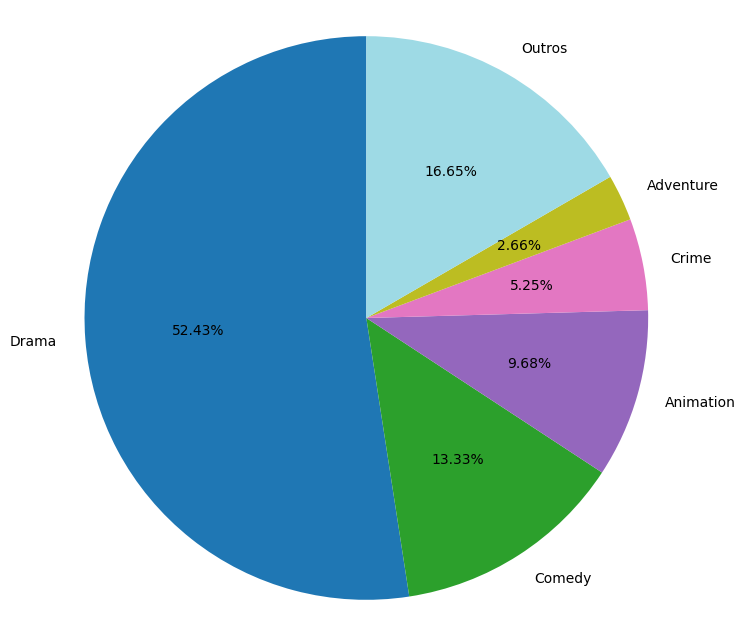

In [29]:
PizzaTopN(df_official_genre_percentual, 5)

In [30]:
df_genre_count = show_raw_data_count_for_year(df_Official, "Genre")
display(df_genre_count)


,Year,Genre,Count
0,1927/28,Action,0
1,1927/28,Adventure,0
2,1927/28,Animation,0
3,1927/28,Comedy,0
4,1927/28,Crime,1
...,...,...,...
1741,2024,Romance,0
1742,2024,Science Fiction,1
1743,2024,Thriller,0
1744,2024,War,0


In [31]:
df_genre_data_analytics = calculate_basics_analitics(df_genre_count, "Genre")
display(df_genre_data_analytics)

,Genre,Média,Mediana,Moda,Amplitude,Desvio
0,Action,0.84,0.0,[0],10,1.583379
1,Adventure,1.20,0.0,[0],12,2.035815
2,Animation,4.39,4.0,[3],10,2.374152
3,Comedy,6.05,5.0,[3],18,4.221402
4,Crime,2.38,1.0,[0],13,2.751679
5,Documentary,0.11,0.0,[0],2,0.349890
6,Drama,23.80,23.0,"[23, 29]",33,6.194149
7,Family,0.41,0.0,[0],4,0.787303
8,Fantasy,0.32,0.0,[0],6,0.909689
9,History,0.64,0.0,[0],6,1.479310


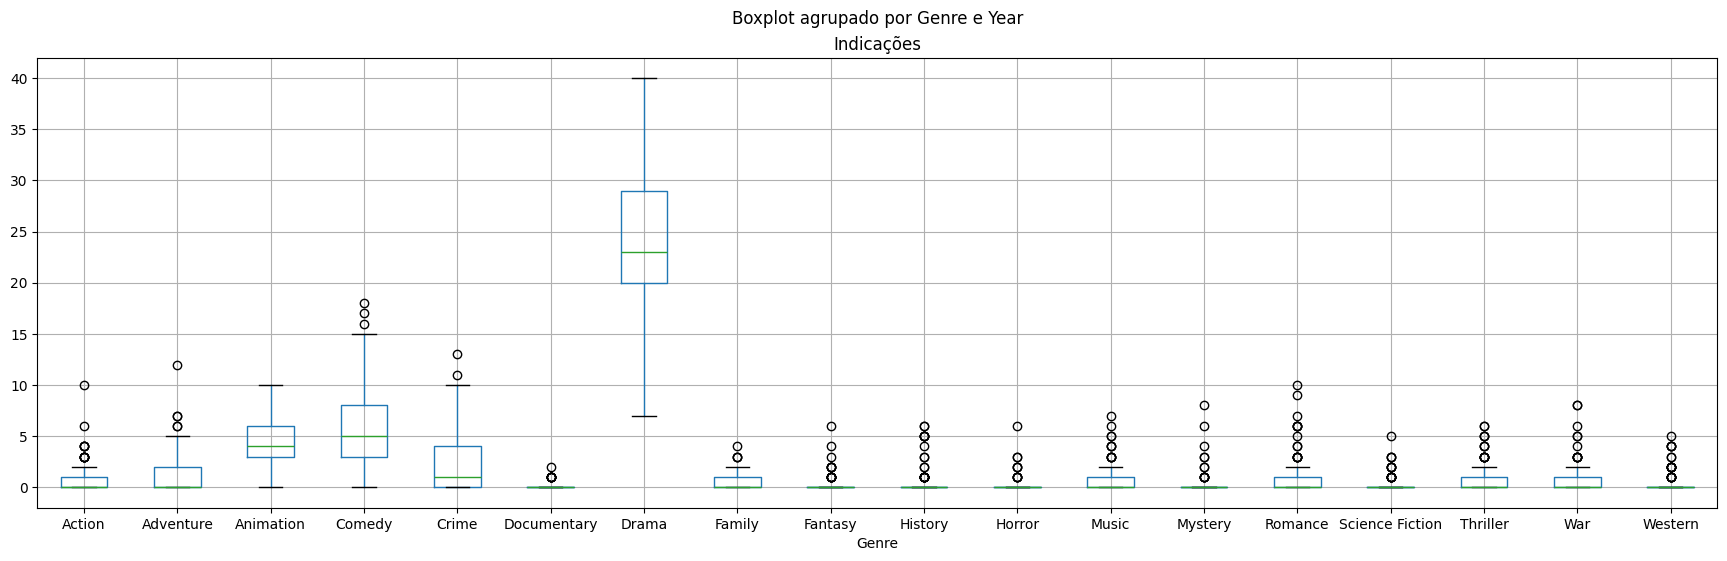

In [32]:
BoxplotByCollumForYears(df_Official, "Genre")

#### Analise dos resultados

Tendo como base toda a amostra de dados foi possível indentificar 17 gêneros presentes nos filmes sendo o mais indicado o de drama representando mais da metade das indicações mais precisamente 52,44%(2309) da amostragem. Finalizando o top cinco temos os seguinte generos:

* Comédia com 13,33%(587)
* Animação com 9,68%(426)
* Crime com 5,25%(231)
* Aventura com 2,66%(117)
<br>
As outras 12 categorias possuem ao todo 16,6%(733) de representação o que demonstra a existência de outras categorias com uma grande representação no sistema.
<br>

Quando fazemos um agrupamento dos generos no passar dos anos é possível avaliar que o gênero de Drama é o unico com presença em todos os anos com no mínimo 7 indicações. Ao todo apenas 4 gêneros possuem uma mediana superior ou igual a um sendo estes o de drama, comédia, animação e crime com apenas os três primeiros tendo um numero diferente de 0 no valor de maior frequência das indicações.
<br>

O boxplot mostra que ao todo 7 gêneros possuem suas caixas totalmente achatadas no 0 e suas indicações totalmente sendo retratadas como outliers mostrando que a presença desses gêneros no evento são apenas esporádicas e todos os outros generos com exceção do drama estão de alguma forma encostados ao número zero, por isso todos os outliers existentes são na parte superior do gráfico.

### Contexto Filme

#### Best Pictures

##### Indicação

In [33]:
df_best_picture = df_Official.copy()
df_best_picture = df_best_picture[df_best_picture["CanonicalCategory"] == "BEST PICTURE"]
df_best_picture = df_best_picture[["CanonicalCategory", "Year", "Film", "Genre", "Winner"]]
display(df_best_picture)

,CanonicalCategory,Year,Film,Genre,Winner
25,BEST PICTURE,1927/28,The Racket,Crime,False
26,BEST PICTURE,1927/28,7th Heaven,Drama,False
27,BEST PICTURE,1927/28,Wings,Drama,True
71,BEST PICTURE,1928/29,Alibi,Crime,False
72,BEST PICTURE,1928/29,In Old Arizona,Western,False
...,...,...,...,...,...
11961,BEST PICTURE,2024,Emilia Pérez,Drama,False
11962,BEST PICTURE,2024,I'm Still Here,Drama,False
11963,BEST PICTURE,2024,Nickel Boys,Drama,False
11964,BEST PICTURE,2024,The Substance,Horror,False


In [34]:
DataFrameInfoTotalCount(df_best_picture, "Genre")

,count
Genre,
Drama,332
Comedy,85
Crime,37
Adventure,26
War,20
Music,19
Action,17
Romance,14
Thriller,12


In [35]:
df_best_picture_genre_percentual = DataFrameInfoPercentual(df_best_picture, "Genre")
display(df_best_picture_genre_percentual)

,Genre,Percentual
0,Drama,54.34
1,Comedy,13.91
2,Crime,6.06
3,Adventure,4.26
4,War,3.27
5,Music,3.11
6,Action,2.78
7,Romance,2.29
8,Thriller,1.96
9,History,1.80


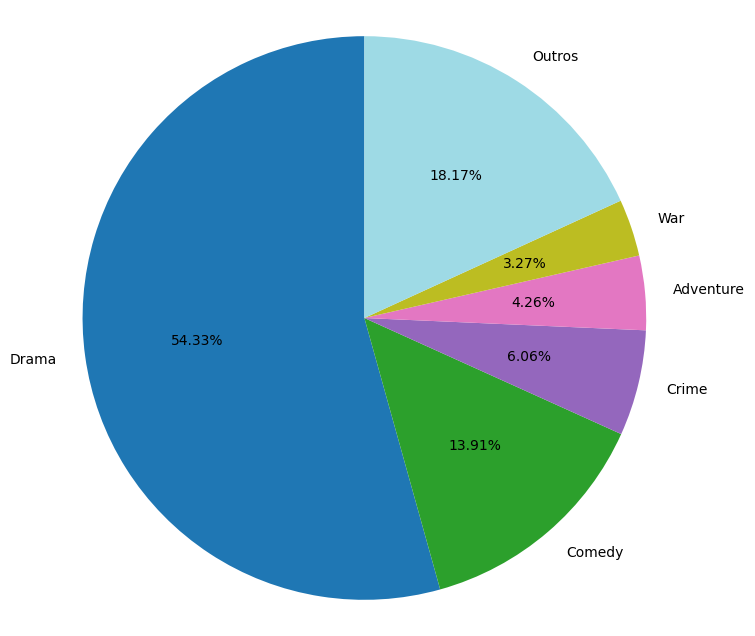

In [36]:
PizzaTopN(df_best_picture_genre_percentual, 5)

In [37]:
df_best_picture_genre_count = show_raw_data_count_for_year(df_best_picture, "Genre")
display(df_best_picture_genre_count)

,Year,Genre,Count
0,1927/28,Action,0
1,1927/28,Adventure,0
2,1927/28,Animation,0
3,1927/28,Comedy,0
4,1927/28,Crime,1
...,...,...,...
1547,2024,Romance,0
1548,2024,Science Fiction,1
1549,2024,Thriller,0
1550,2024,War,0


In [38]:
df_best_picture_genre_data_analytics = calculate_basics_analitics(df_best_picture_genre_count, "Genre")
display(df_best_picture_genre_data_analytics)

,Genre,Média,Mediana,Moda,Amplitude,Desvio
0,Action,0.17,0.0,[0],3,0.456671
1,Adventure,0.26,0.0,[0],3,0.568541
2,Animation,0.03,0.0,[0],1,0.174022
3,Comedy,0.87,1.0,[0],4,0.971015
4,Crime,0.38,0.0,[0],2,0.567217
5,Drama,3.42,3.0,"[2, 3]",7,1.526400
6,Fantasy,0.07,0.0,[0],1,0.260105
7,History,0.11,0.0,[0],2,0.349890
8,Horror,0.03,0.0,[0],1,0.174022
9,Music,0.19,0.0,[0],3,0.513143


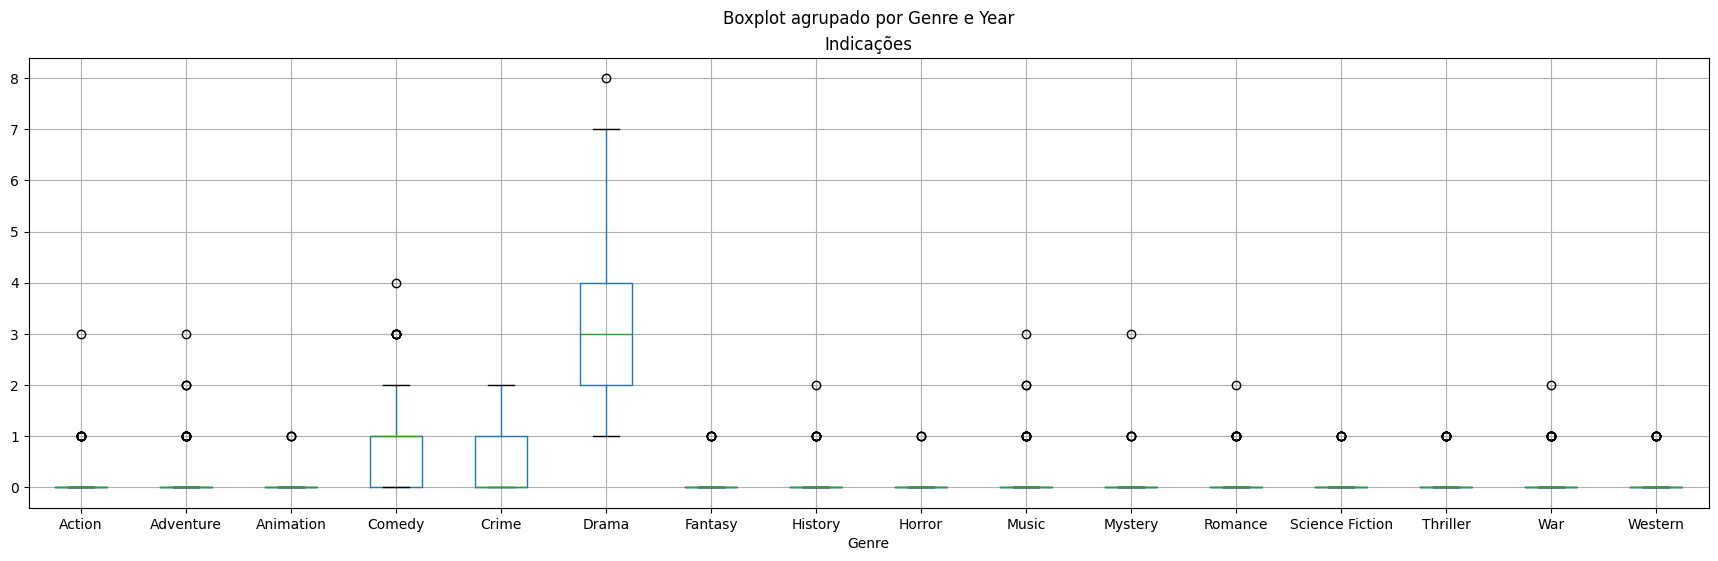

In [39]:
BoxplotByCollumForYears(df_best_picture, "Genre")

##### Vitória Categoria

In [40]:
df_best_picture_winner = df_best_picture[df_best_picture["Winner"] == True]
display(df_best_picture_winner)

,CanonicalCategory,Year,Film,Genre,Winner
27,BEST PICTURE,1927/28,Wings,Drama,True
73,BEST PICTURE,1928/29,The Broadway Melody,Music,True
118,BEST PICTURE,1929/30,All Quiet on the Western Front,War,True
158,BEST PICTURE,1930/31,Cimarron,Western,True
202,BEST PICTURE,1931/32,Grand Hotel,Drama,True
...,...,...,...,...,...
11438,BEST PICTURE,2020,Nomadland,Drama,True
11555,BEST PICTURE,2021,CODA,Drama,True
11682,BEST PICTURE,2022,Everything Everywhere All at Once,Action,True
11817,BEST PICTURE,2023,Oppenheimer,Drama,True


In [41]:
DataFrameInfoTotalCount(df_best_picture_winner, "Genre")

,count
Genre,
Drama,60
Comedy,11
Adventure,5
Action,4
Crime,4
War,3
Music,3
History,3
Western,2


In [42]:
df_best_picture_winner_genre_percentual = DataFrameInfoPercentual(df_best_picture_winner, "Genre")
display(display(df_best_picture_winner_genre_percentual))

,Genre,Percentual
0,Drama,61.86
1,Comedy,11.34
2,Adventure,5.15
3,Action,4.12
4,Crime,4.12
5,War,3.09
6,Music,3.09
7,History,3.09
8,Western,2.06
9,Mystery,1.03


None

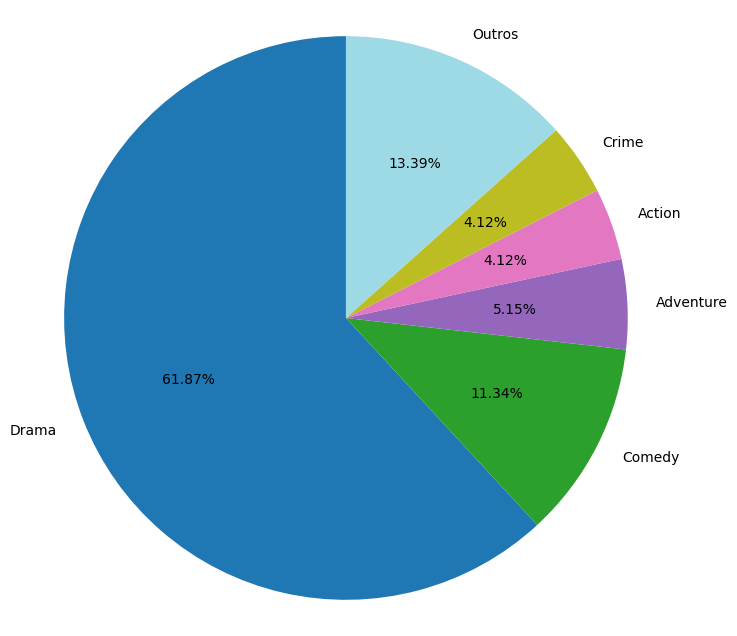

In [43]:
PizzaTopN(df_best_picture_winner_genre_percentual, 5)

In [44]:
last_show_information(df_best_picture_winner, "Genre")

,Genre,LastYear,YearsWithout
0,Drama,2024,0
1,Music,1951,73
2,War,1970,54
3,Western,1992,32
4,Comedy,2019,5
5,Adventure,2003,21
6,Mystery,1940,84
7,Crime,2007,17
8,History,1985,39
9,Action,2022,2


##### Análise do Resultado

No contexto de indicação foram indicados ao todo 611 filmes desde a primeira edição sendo estes filmes subdivididos em 16 categorias sendo as top 5 as:

* Drama com 54,34%(332)
* Comédia com 13,91%(85)
* Crime com 6,06%(37)
* Aventura com 4,26%(26)
* Guerra com 3,27%(20)
<br>
Os outros gêneros são responsáveis por aproximadamente 18,17%(111) dos resultados mostrando que a representação das outras categorias ainda tem um impacto em números absolutos na categoria, mas de maneira relativa ja vão ficando menos expressivas.
<br>

Agora na análise dos gêneros agrupados ao longo dos anos um ponto que chamou bastante a atenção foi que a quantidade de indicações com maior frequência foi nenhuma indicação com exceção do gênero drama que empataram 2 ou 3 indicações isso nos mostra que a indicações do generos possuem uma boa variação dos generos nas indicações de melhor filme.
<br>

Quando plotamos os dados no boxplot fica evidente essa alta variação nos generos em que mostram 13 generos completamente achatados na 0 indicação. Mais uma vez o genero drama mostrou uma alta variação, entre 1 e 8, no numero de indicações, assim sempre se mantendo presente na premiação.
<br>

Concentrando a análise apenas com filmes vencedores do oscar na categoria  verificamos que o percentual de Drama na composição é maior que no numero de indicações com 61,86% resultando em 60 premiações. Além do aumento proporcional no genero de drama algumas modificações no ranking foram relatadas como a saida do genero de guerra para a entrada dos filmes de ação, além das mudanças de posições dos gêneros. A lista completa dos gêneros ficou:

* Drama com 61,86%(60)
* Comedia com 11,34%(11)
* Aventura com 5,15%(5)
* Ação com 4,12%(4)
* Crime com 4,12(4)
* Outros com 13,39%(13)
<br>
Esses 5 generos vem sendo a escolha de melhor filme nas ultimas 21 edições sendo o Genero de Drama o ultimo vencedor e o de aventura a sua ultima vitória foi no ano de 2003 com o filme O Senhor dos Anéis: O Retorno do Rei.

#### International Pictures

##### Analise Por Genero

###### Indicações

In [45]:
df_international_picture = df_Official.copy()
df_international_picture = df_international_picture[df_international_picture["CanonicalCategory"] == "INTERNATIONAL FEATURE FILM"]
df_international_picture = df_international_picture[["CanonicalCategory", "Year", "Film", "Genre", "Winner"]]
display(df_international_picture)

,CanonicalCategory,Year,Film,Genre,Winner
2637,INTERNATIONAL FEATURE FILM,1950,The Walls of Malapaga,Drama,True
2759,INTERNATIONAL FEATURE FILM,1951,Rashomon,Crime,True
2892,INTERNATIONAL FEATURE FILM,1952,Forbidden Games,Drama,True
3160,INTERNATIONAL FEATURE FILM,1954,Gate of Hell,Drama,True
3298,INTERNATIONAL FEATURE FILM,1955,"Samurai, The Legend of Musashi",Drama,True
...,...,...,...,...,...
11936,INTERNATIONAL FEATURE FILM,2024,Emilia Pérez,Drama,False
11937,INTERNATIONAL FEATURE FILM,2024,Flow,Animation,False
11938,INTERNATIONAL FEATURE FILM,2024,The Girl with the Needle,Drama,False
11939,INTERNATIONAL FEATURE FILM,2024,I'm Still Here,Drama,True


In [46]:
DataFrameInfoTotalCount(df_international_picture, "Genre")

,count
Genre,
Drama,220
Comedy,54
Romance,11
Crime,10
War,9
Adventure,9
Action,8
History,7
Documentary,6


In [47]:
df_international_genre_percentual = DataFrameInfoPercentual(df_international_picture, "Genre")
display(df_international_genre_percentual)

,Genre,Percentual
0,Drama,62.86
1,Comedy,15.43
2,Romance,3.14
3,Crime,2.86
4,War,2.57
5,Adventure,2.57
6,Action,2.29
7,History,2.00
8,Documentary,1.71
9,Animation,0.86


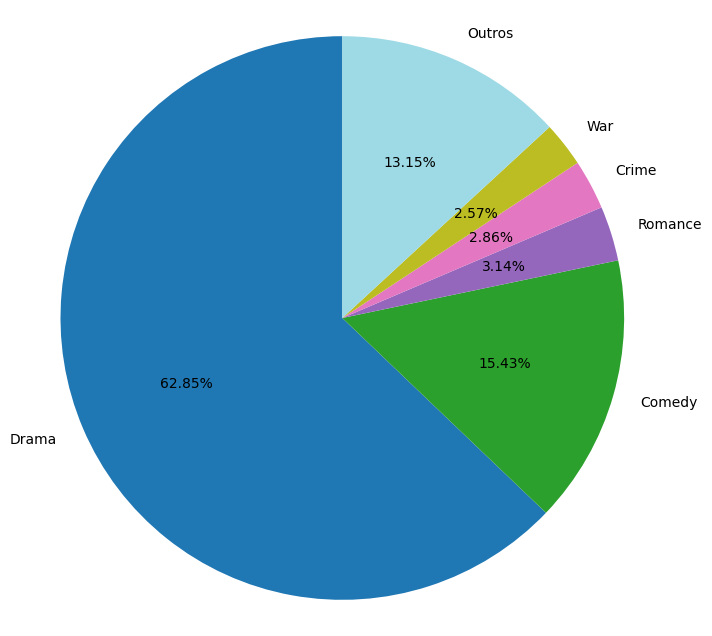

In [48]:
PizzaTopN(df_international_genre_percentual, 5)

In [49]:
df_international_picture_genre_count = show_raw_data_count_for_year(df_international_picture, "Genre")
display(df_international_picture_genre_count)

,Year,Genre,Count
0,1950,Action,0
1,1950,Adventure,0
2,1950,Animation,0
3,1950,Comedy,0
4,1950,Crime,0
...,...,...,...
1253,2024,Mystery,0
1254,2024,Romance,0
1255,2024,Science Fiction,0
1256,2024,Thriller,0


In [50]:
df_best_picture_genre_data_analytics = calculate_basics_analitics(df_international_picture_genre_count, "Genre")
display(df_best_picture_genre_data_analytics)

,Genre,Média,Mediana,Moda,Amplitude,Desvio
0,Action,0.10,0.0,[0],2,0.353750
1,Adventure,0.12,0.0,[0],1,0.329079
2,Animation,0.04,0.0,[0],1,0.198569
3,Comedy,0.72,0.5,[0],3,0.880493
4,Crime,0.13,0.0,[0],2,0.416256
5,Documentary,0.08,0.0,[0],1,0.274823
6,Drama,2.97,3.0,[4],5,1.249361
7,Family,0.04,0.0,[0],1,0.198569
8,Fantasy,0.02,0.0,[0],1,0.163269
9,History,0.09,0.0,[0],2,0.337960


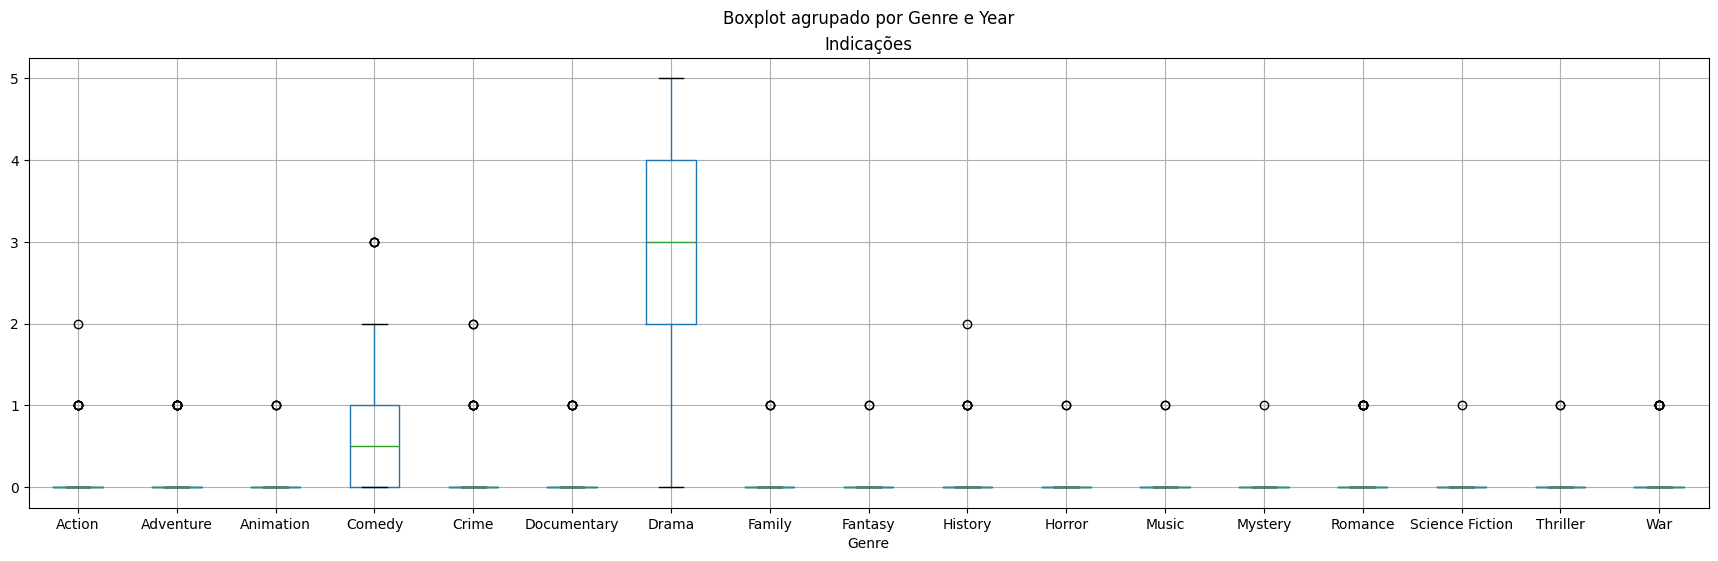

In [51]:
BoxplotByCollumForYears(df_international_picture,"Genre")

###### Vitória Categoria

In [52]:
df_international_picture_winner = df_international_picture[df_international_picture["Winner"] == True]
display(df_international_picture_winner)

,CanonicalCategory,Year,Film,Genre,Winner
2637,INTERNATIONAL FEATURE FILM,1950,The Walls of Malapaga,Drama,True
2759,INTERNATIONAL FEATURE FILM,1951,Rashomon,Crime,True
2892,INTERNATIONAL FEATURE FILM,1952,Forbidden Games,Drama,True
3160,INTERNATIONAL FEATURE FILM,1954,Gate of Hell,Drama,True
3298,INTERNATIONAL FEATURE FILM,1955,"Samurai, The Legend of Musashi",Drama,True
...,...,...,...,...,...
11414,INTERNATIONAL FEATURE FILM,2020,Another Round,Comedy,True
11534,INTERNATIONAL FEATURE FILM,2021,Drive My Car,Drama,True
11658,INTERNATIONAL FEATURE FILM,2022,All Quiet on the Western Front,War,True
11795,INTERNATIONAL FEATURE FILM,2023,The Zone of Interest,Drama,True


In [53]:
DataFrameInfoTotalCount(df_international_picture_winner, "Genre")

,count
Genre,
Drama,47
Comedy,12
War,3
Crime,2
History,2
Adventure,2
Documentary,1
Thriller,1
Romance,1


In [54]:
df_international_winner_genre_percentual = DataFrameInfoPercentual(df_international_picture_winner, "Genre")
display(df_international_winner_genre_percentual)

,Genre,Percentual
0,Drama,63.51
1,Comedy,16.22
2,War,4.05
3,Crime,2.70
4,History,2.70
5,Adventure,2.70
6,Documentary,1.35
7,Thriller,1.35
8,Romance,1.35
9,Fantasy,1.35


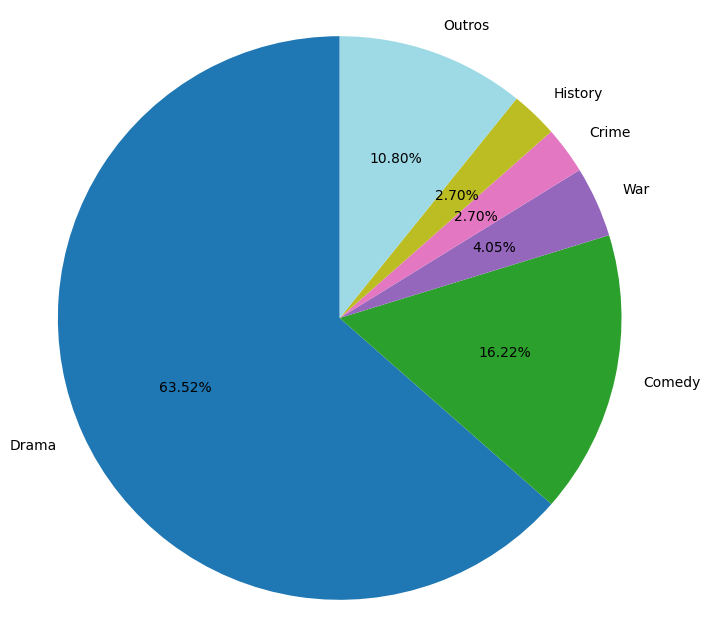

In [55]:
PizzaTopN(df_international_winner_genre_percentual, 5)

In [56]:
last_show_information(df_international_picture_winner, "Genre")

,Genre,LastYear,YearsWithout
0,Drama,2024,0
1,Crime,2005,19
2,Comedy,2020,4
3,History,1997,27
4,Thriller,1969,55
5,Documentary,1974,50
6,Adventure,2000,24
7,Romance,1978,46
8,Fantasy,1983,41
9,War,2022,2


###### Analise do Resultado

Nos filmes internacionais tiveram 74 premiações e ocorrem desde o ano de 1950 o que resultou ao todo 350 indicações sendo que nas primeiras 5 edições só existia um único filme indicado logo era automaticamente o vencedor. Ao todo 17 gêneros foram contemplados neste modelo de premiação com o ranking de top 5 sendo responsável por um total 86,85% das indicações com um total de 304 indicações e os demais generos representando 13,15%, ou seja, 46 indicações de maneira absoluta. Segue a composição do top 5:
* Drama: 62,86%(220)
* Comedia: 15,43%(54)
* Romance: 3,14%(11)
* Crime: 2,86%(10)
* Guerra: 2,57%(9)
<br>
Para a analise dos gêneros agrupados ao longo dos anos tivemos um resultado o bastante similar com os de melhores filmes com a maioria dos genero possuindo 0 indicações como o valor predominante na quantidade de indicações por ano resultando assim uma baixa amplitude o desvio padrão mostrando os dados bastante homogêneo. O único genero que se mostrou distinto mais uma vez foi o de Drama possuindo uma Moda de 4 indicações tendo uma mediana de 3 indicações e um desvio acima de 1.
<br>

Quando plotamos um gráfico de boxplot isso fica mais evidente com apenas os generos de Drama e de Comédia não ficando totalmente achatados com 0 indicações. Outro ponto que vale destacar foi que 12 gêneros só possuem outliers indicando apenas uma indicação. Outro ponto a ser destacado que ao contrário dos ultimos dois grupos o genero drama aqui chegou a ter anos em que 0 filmes foram indicados ao prêmio, tais situações ocorreram nos anos de 1951, 1968 e 2001.
<br>

Quando concentramos as análises apenas para os gêneros vencedores o número de generos felizardos com a vitória cai para 12 e os top 5 no ranking sofrem algumas alterações. Onde o gênero de romance decai no ranking e é substituido pelo gênero de história terminando o ranking da seguinte maneira:
* Drama: 63,51%(47)
* Comedia: 16,22%(12)
* Guerra: 4,05%(3)
* Crime: 2,70%(2)
* História: 2,70%(2)
* Outros: 10,82%(8)
<br>

Dos 5 mais vitóriosos o genero de História é o que está a mais tempo sem conquistar um oscar sendo a ultima vez no ano de 1997, 27 anos atrás, sendo um período de tempo mais distante que outros gêneros não pertencente ao top 5 como aventura, ação e mistério.

##### Analise Por *País*

###### Indicações

In [57]:
df_international_picture_country = df_Official.copy()
df_international_picture_country = df_international_picture_country[df_international_picture_country["CanonicalCategory"] == "INTERNATIONAL FEATURE FILM"]
df_international_picture_country = df_international_picture_country[["Year","Film", "Name", "Winner"]]
display(df_international_picture_country)

,Year,Film,Name,Winner
2637,1950,The Walls of Malapaga,Italy,True
2759,1951,Rashomon,Japan,True
2892,1952,Forbidden Games,France,True
3160,1954,Gate of Hell,Japan,True
3298,1955,"Samurai, The Legend of Musashi",Japan,True
...,...,...,...,...
11936,2024,Emilia Pérez,France,False
11937,2024,Flow,Latvia,False
11938,2024,The Girl with the Needle,Denmark,False
11939,2024,I'm Still Here,Brazil,True


In [58]:
DataFrameInfoTotalCount(df_international_picture_country, "Name")

,count
Name,
France,40
Italy,31
Spain,21
Japan,18
Sweden,16
...,...
Tunisia,1
Bosnia and Herzegovina,1
Bhutan,1


In [59]:
df_international_country_percentual = DataFrameInfoPercentual(df_international_picture_country, "Name")
display(df_international_country_percentual)

,Name,Percentual
0,France,11.43
1,Italy,8.86
2,Spain,6.00
3,Japan,5.14
4,Sweden,4.57
...,...,...
64,Tunisia,0.29
65,Bosnia and Herzegovina,0.29
66,Bhutan,0.29
67,Ireland,0.29


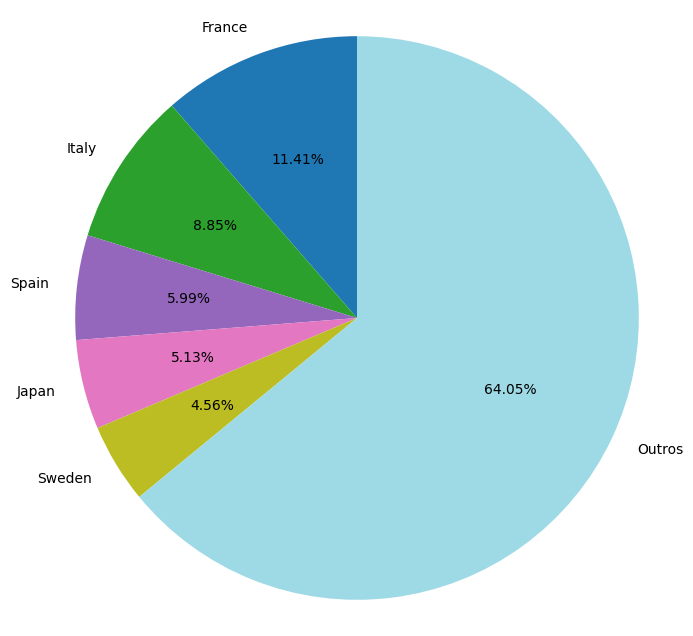

In [60]:
PizzaTopN(df_international_country_percentual, 5)

In [61]:
last_show_information(df_international_picture_country, "Name")

,Name,LastYear,YearsWithout
0,Italy,2023,1
1,Japan,2023,1
2,France,2024,0
3,West Germany,1973,51
4,Denmark,2024,0
...,...,...,...
64,Tunisia,2020,4
65,Bosnia and Herzegovina,2020,4
66,Bhutan,2021,3
67,Ireland,2022,2


###### Vitória Categoria

In [62]:
df_international_picture_country_winner = df_international_picture_country[df_international_picture_country["Winner"] == True]
display(df_international_picture_winner)

,CanonicalCategory,Year,Film,Genre,Winner
2637,INTERNATIONAL FEATURE FILM,1950,The Walls of Malapaga,Drama,True
2759,INTERNATIONAL FEATURE FILM,1951,Rashomon,Crime,True
2892,INTERNATIONAL FEATURE FILM,1952,Forbidden Games,Drama,True
3160,INTERNATIONAL FEATURE FILM,1954,Gate of Hell,Drama,True
3298,INTERNATIONAL FEATURE FILM,1955,"Samurai, The Legend of Musashi",Drama,True
...,...,...,...,...,...
11414,INTERNATIONAL FEATURE FILM,2020,Another Round,Comedy,True
11534,INTERNATIONAL FEATURE FILM,2021,Drive My Car,Drama,True
11658,INTERNATIONAL FEATURE FILM,2022,All Quiet on the Western Front,War,True
11795,INTERNATIONAL FEATURE FILM,2023,The Zone of Interest,Drama,True


In [63]:
DataFrameInfoTotalCount(df_international_picture_country_winner, "Name")

,count
Name,
Italy,12
France,10
Japan,5
Spain,4
Denmark,4
Union of Soviet Socialist Republics,3
The Netherlands,3
Sweden,3
Germany,3


In [64]:
df_international_country_winner_percentual = DataFrameInfoPercentual(df_international_picture_country_winner, "Name")
display(df_international_country_winner_percentual)

,Name,Percentual
0,Italy,16.22
1,France,13.51
2,Japan,6.76
3,Spain,5.41
4,Denmark,5.41
5,Union of Soviet Socialist Republics,4.05
6,The Netherlands,4.05
7,Sweden,4.05
8,Germany,4.05
9,Czechoslovakia,2.70


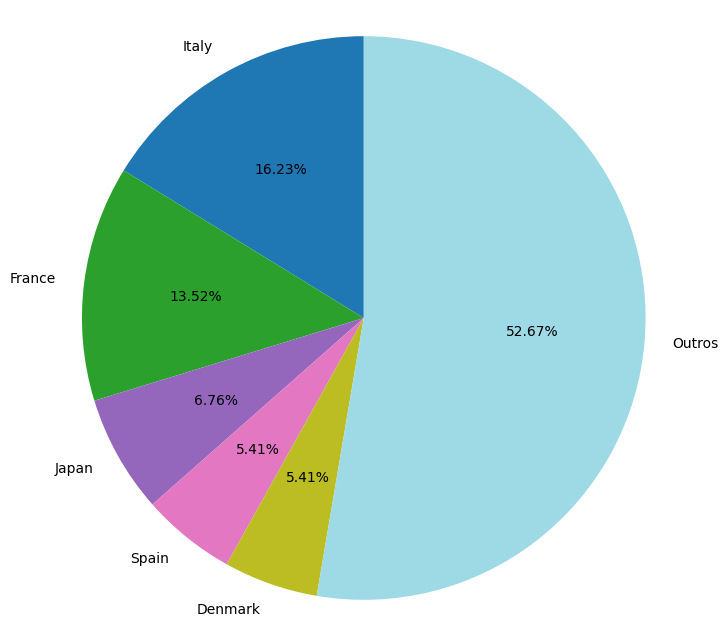

In [65]:
PizzaTopN(df_international_country_winner_percentual, 5)

In [195]:
last_show_information(df_international_picture_country_winner, "Name")

,Name,LastYear,YearsWithout
0,Italy,2013,11
1,Japan,2021,3
2,France,1992,32
3,Sweden,1983,41
4,Czechoslovakia,1967,57
5,Union of Soviet Socialist Republics,1980,44
6,Algeria,1969,55
7,Ivory Coast,1976,48
8,Federal Republic of Germany,1979,45
9,Hungary,2015,9


###### Analise do Resultado

Passando a analisar o contexto geográfico de países 69 foram selecionados para participar da premiação. Nessa categoria os países europeus dominaram a presença no top 5 sendo representados por 4 países sendo estes França com 11,43%(40) das indicações, Itália com 8,86%(31), Espanha com 6%(21) e Suécia 4,57%(16). O único que conseguiu furar essa bolha européia foi o Japão com 5,14%(18) e o restante dos países estão agrupados em outros com um total de 64%(224) o que demonstra que não existe um país dominante no processo de indicações ao prêmio de melhor filme internacional.
<br>

No contexto de vitória a quantidade de países que conseguiram levar para a casa o prêmio fo reduzido para o número de 30 países, entre eles o Brasil sendo esta sua unica estatueta de ouro no oscar com o filme Ainda estou aqui. O top 5 países vencedores foram a Itália que teve um percentual de praticamente o dobro em relação as indicações representando 16,22%(12). Seguidos por França 13,51%(10), Japão 6,76%(5), Espanha 5,41%(4) e Dinamarca também com 5,41%(4), os outros países superaram novamente a barreira da metade dos dados com 52,69%(39).
<br>

Nos ultimos anos dos paises que se encontram no Top 5 apenas o Japão e a Dinamarca foram premiados nesses ultimos 10 anos que teve um país diferente vencendo em cada edição. O país do top 5 que está a mais tempo sem receber o Oscar da categoria é a França que a ultima conquista foi no ano de 1992.

#### Animation Pictures

##### Indicacao

In [67]:
df_animation_picture = df_Official.copy()
df_animation_picture = df_animation_picture[df_animation_picture["CanonicalCategory"].isin(["ANIMATED FEATURE FILM", "SHORT FILM (Animated)"])]
df_animation_picture = df_animation_picture[["CanonicalCategory", "Year", "Film", "Genre", "Winner"]]
display(df_animation_picture)

,CanonicalCategory,Year,Film,Genre,Winner
206,SHORT FILM (Animated),1931/32,Flowers and Trees,Animation,True
207,SHORT FILM (Animated),1931/32,It's Got Me Again,Animation,False
208,SHORT FILM (Animated),1931/32,Mickey's Orphans,Animation,False
273,SHORT FILM (Animated),1932/33,Building a Building,Animation,False
274,SHORT FILM (Animated),1932/33,The Merry Old Soul,Animation,False
...,...,...,...,...,...
11901,SHORT FILM (Animated),2024,Beautiful Men,Animation,False
11902,SHORT FILM (Animated),2024,In the Shadow of the Cypress,Animation,True
11903,SHORT FILM (Animated),2024,Magic Candies,Animation,False
11904,SHORT FILM (Animated),2024,Wander to Wonder,Animation,False


In [68]:
DataFrameInfoTotalCount(df_animation_picture, "Genre")

,count
Genre,
Animation,413
Family,31
Comedy,16
Adventure,10
Drama,7
Action,4
Music,4
Documentary,4
Science Fiction,4


In [69]:
df_animation_picture_genre_percentual = DataFrameInfoPercentual(df_animation_picture, "Genre")
display(display(df_animation_picture_genre_percentual))

,Genre,Percentual
0,Animation,82.27
1,Family,6.18
2,Comedy,3.19
3,Adventure,1.99
4,Drama,1.39
5,Action,0.80
6,Music,0.80
7,Documentary,0.80
8,Science Fiction,0.80
9,Fantasy,0.60


None

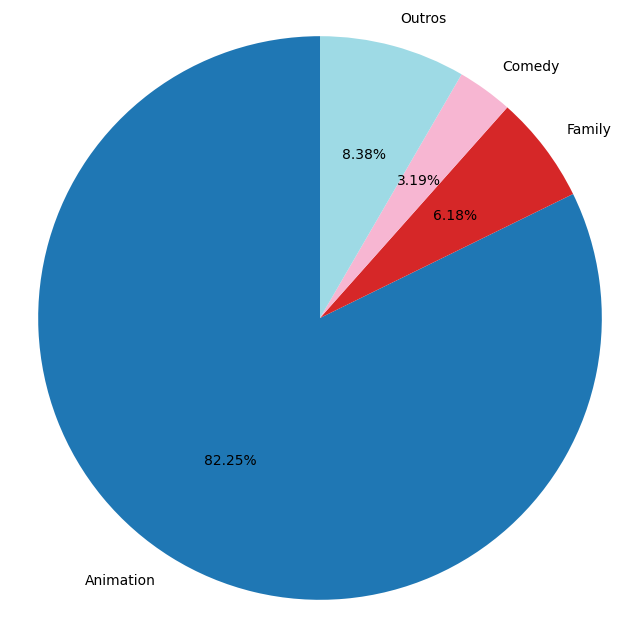

In [198]:
PizzaTopN(df_animation_picture_genre_percentual, 3)

In [71]:
df_animation_picture_genre_count = show_raw_data_count_for_year(df_animation_picture, "Genre")
display(df_animation_picture_genre_count)

,Year,Genre,Count
0,1931/32,Action,0
1,1931/32,Adventure,0
2,1931/32,Animation,3
3,1931/32,Comedy,0
4,1931/32,Documentary,0
...,...,...,...
1204,2024,History,0
1205,2024,Horror,0
1206,2024,Music,0
1207,2024,Romance,0


In [72]:
df_animation_picture_genre_data_analytics = calculate_basics_analitics(df_animation_picture_genre_count, "Genre")
display(df_animation_picture_genre_data_analytics)

,Genre,Média,Mediana,Moda,Amplitude,Desvio
0,Action,0.04,0.0,[0],1,0.203981
1,Adventure,0.10,0.0,[0],2,0.344597
2,Animation,4.44,4.0,[3],9,2.113427
3,Comedy,0.17,0.0,[0],1,0.379463
4,Documentary,0.04,0.0,[0],1,0.203981
5,Drama,0.07,0.0,[0],1,0.265255
6,Family,0.33,0.0,[0],3,0.681005
7,Fantasy,0.03,0.0,[0],1,0.177642
8,History,0.01,0.0,[0],1,0.103695
9,Horror,0.03,0.0,[0],2,0.230859


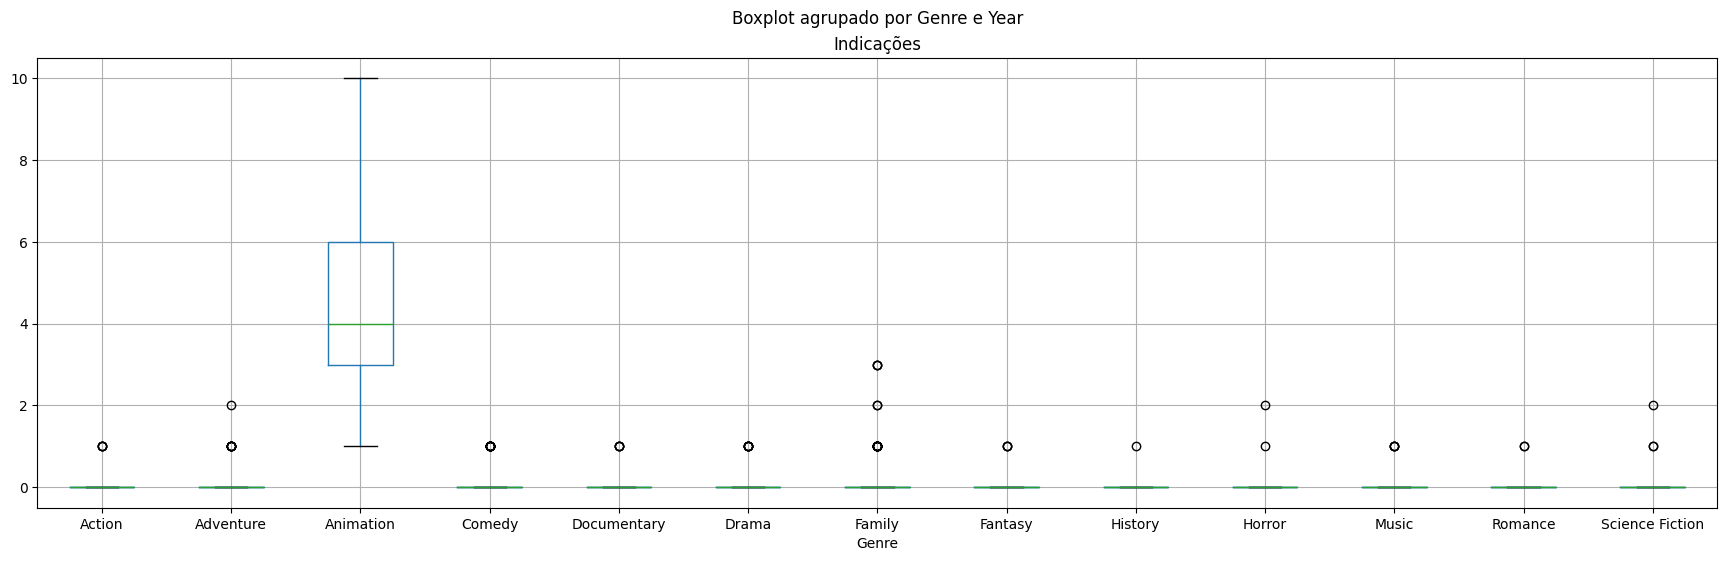

In [73]:
BoxplotByCollumForYears(df_animation_picture, "Genre")

##### Vitoria Categoria

In [74]:
df_animation_picture_winner = df_animation_picture[df_animation_picture["Winner"] == True]
display(df_animation_picture_winner)

,CanonicalCategory,Year,Film,Genre,Winner
206,SHORT FILM (Animated),1931/32,Flowers and Trees,Animation,True
275,SHORT FILM (Animated),1932/33,The Three Little Pigs,Music,True
337,SHORT FILM (Animated),1934,The Tortoise and the Hare,Animation,True
424,SHORT FILM (Animated),1935,Three Orphan Kittens,Animation,True
533,SHORT FILM (Animated),1936,The Country Cousin,Animation,True
...,...,...,...,...,...
11693,SHORT FILM (Animated),2022,"The Boy, the Mole, the Fox and the Horse",Animation,True
11756,ANIMATED FEATURE FILM,2023,The Boy and the Heron,Animation,True
11830,SHORT FILM (Animated),2023,WAR IS OVER! Inspired by the Music of John & Yoko,Animation,True
11896,ANIMATED FEATURE FILM,2024,Flow,Animation,True


In [75]:
DataFrameInfoTotalCount(df_animation_picture_winner, "Genre")

,count
Genre,
Animation,97
Family,6
Comedy,5
Adventure,3
Drama,2
Documentary,2
Music,1
Action,1


In [76]:
df_animation_picture_winner_genre_percentual = DataFrameInfoPercentual(df_animation_picture_winner, "Genre")
display(df_animation_picture_winner_genre_percentual)

,Genre,Percentual
0,Animation,82.91
1,Family,5.13
2,Comedy,4.27
3,Adventure,2.56
4,Drama,1.71
5,Documentary,1.71
6,Music,0.85
7,Action,0.85


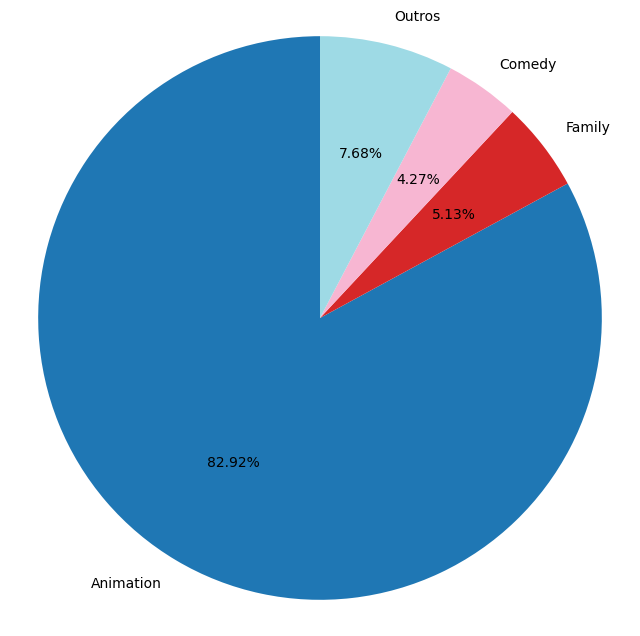

In [199]:
PizzaTopN(df_animation_picture_winner_genre_percentual, 3)

In [200]:
last_show_information(df_animation_picture_winner, "Genre")

,Genre,LastYear,YearsWithout
0,Animation,2024,0
1,Music,1932/33,92
2,Family,2019,5
3,Comedy,1994,30
4,Documentary,2004,20
5,Drama,2020,4
6,Action,2004,20
7,Adventure,2014,10


##### Analise do Resultado

Para a análise do desempenho das animações do oscar juntou as informações das categorias de melhor animação e melhor curta de animação o que resultou em um dataframe de 502 entradas, sendo estes filmes subdivididos em 13 categorias em que mostrou uma clara predominância do gênero de animação, por motivos óbvios, com um total de 82,27%(413) das indicações. Fechando o top 3 temos os gêneros de familia com 6,18%(31) e comédia com 3,19%(16). Os demais gêneros ficam com 8,36%(42) das indicações.
<br>

Quando fazemos o agrupamento do numero de gêneros indicados em cada ano a predominância  do genero animação fica evidente, pois todos os outros generos possuem valor zerado na mediana, o valor predominante de indicações é zero, possuem uma baixa amplitude variando entre 1 e 3 a depender do genero e um desvio menor do que um o que plotado no gráfico de boxplot acaba gerando caixas totalmente achatadas no zero e todos os valores de amplitude acabam virando outliers. Agora no genero de animação é o unico que teve pelo menos uma indicação em todos os anos podendo chegar até a 10, mas sua mediana de indicações é 4 e com uma maior frequência de três indicações.
<br>

Focando agora apenas ns títulos vencedores o numero de generos é reduzido para um total de 8 generos, mas a concentração no genero de animação persiste com um total de 82.91%(97) dos vencedores pertencentes a esse gênero. Fechando o Top 3 fica o familia com 5,13%(6) e comédia 4,27%(5) deixando apenas 7,69% pros outros gêneros(9).
<br>

Por fim os ultimos 3 gêneros que receberam o grande prêmio foram o de animação, drama e familia. Deixando o genero de comédia que pertence ao top 3 tanto em indicações como em vitórias tendo recebido seu ultimo prêmio a 30 anos em 1994 com o título Bob's Birthday na categoria de curta de animação.

### Contexto Humano

#### Actors In Leading Role

##### Genero

###### Indicações

In [79]:
df_actors_leading_role = df_Official.copy()
df_actors_leading_role = df_actors_leading_role[df_actors_leading_role["CanonicalCategory"].isin(["ACTOR IN A LEADING ROLE", "ACTRESS IN A LEADING ROLE"])]
df_actors_leading_role = df_actors_leading_role[["CanonicalCategory", "Year", "Film", "Genre", "Nominees", "Winner"]]
display(df_actors_leading_role)

,CanonicalCategory,Year,Film,Genre,Nominees,Winner
0,ACTOR IN A LEADING ROLE,1927/28,The Noose,Drama,Richard Barthelmess,False
1,ACTOR IN A LEADING ROLE,1927/28,The Patent Leather Kid,War,Richard Barthelmess,False
2,ACTOR IN A LEADING ROLE,1927/28,The Last Command,Drama,Emil Jannings,True
3,ACTOR IN A LEADING ROLE,1927/28,The Way of All Flesh,Drama,Emil Jannings,True
4,ACTRESS IN A LEADING ROLE,1927/28,A Ship Comes In,Drama,Louise Dresser,False
...,...,...,...,...,...,...
11886,ACTRESS IN A LEADING ROLE,2024,Wicked,Drama,Cynthia Erivo,False
11887,ACTRESS IN A LEADING ROLE,2024,Emilia Pérez,Drama,Karla Sofía Gascón,False
11888,ACTRESS IN A LEADING ROLE,2024,Anora,Drama,Mikey Madison,True
11889,ACTRESS IN A LEADING ROLE,2024,The Substance,Horror,Demi Moore,False


In [80]:
DataFrameInfoTotalCount(df_actors_leading_role, "Genre")

,count
Genre,
Drama,629
Comedy,122
Crime,51
Romance,31
Thriller,23
Music,22
Adventure,15
War,15
History,14


In [81]:
df_actors_leading_genre_percentual = DataFrameInfoPercentual(df_actors_leading_role, "Genre")

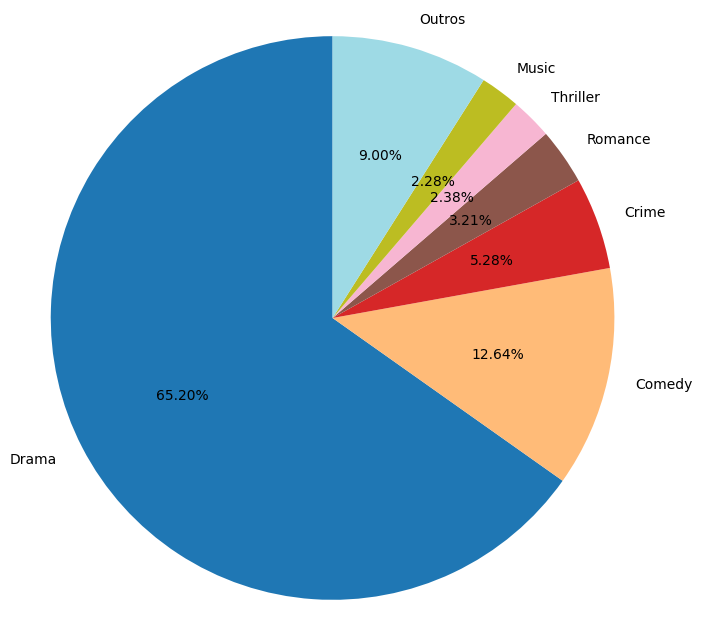

In [82]:
PizzaTopN(df_actors_leading_genre_percentual, 6)

In [83]:
df_actors_leading_genre_count = show_raw_data_count_for_year(df_actors_leading_role, "Genre")
display(df_actors_leading_genre_count)

,Year,Genre,Count
0,1927/28,Action,0
1,1927/28,Adventure,0
2,1927/28,Animation,0
3,1927/28,Comedy,0
4,1927/28,Crime,0
...,...,...,...
1644,2024,Romance,0
1645,2024,Science Fiction,0
1646,2024,Thriller,0
1647,2024,War,0


In [84]:
df_actors_leading_genre_data_analytics = calculate_basics_analitics(df_actors_leading_genre_count, "Genre")
display(df_actors_leading_genre_data_analytics)

,Genre,Média,Mediana,Moda,Amplitude,Desvio
0,Action,0.09,0.0,[0],2,0.325400
1,Adventure,0.15,0.0,[0],3,0.441121
2,Animation,0.03,0.0,[0],2,0.226090
3,Comedy,1.25,1.0,[1],5,1.166176
4,Crime,0.52,0.0,[0],3,0.737292
5,Drama,6.48,7.0,[6],8,1.633716
6,Family,0.01,0.0,[0],1,0.101535
7,Fantasy,0.03,0.0,[0],1,0.174022
8,History,0.14,0.0,[0],2,0.381600
9,Horror,0.04,0.0,[0],1,0.199871


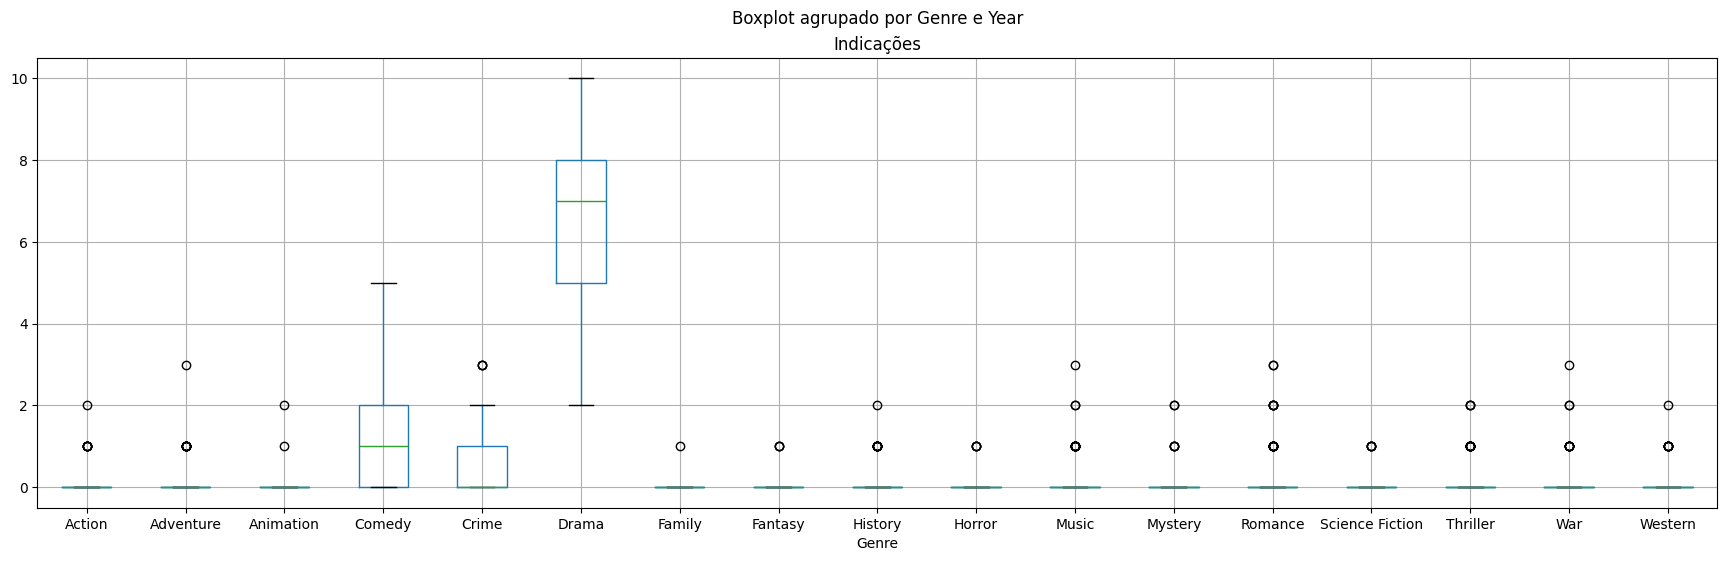

In [85]:
BoxplotByCollumForYears(df_actors_leading_role, "Genre")

###### Vitórias na Categoria

In [86]:
df_actors_leading_role_winner = df_actors_leading_role[df_actors_leading_role["Winner"] == True]
display(df_actors_leading_role_winner)

,CanonicalCategory,Year,Film,Genre,Nominees,Winner
2,ACTOR IN A LEADING ROLE,1927/28,The Last Command,Drama,Emil Jannings,True
3,ACTOR IN A LEADING ROLE,1927/28,The Way of All Flesh,Drama,Emil Jannings,True
5,ACTRESS IN A LEADING ROLE,1927/28,7th Heaven,Drama,Janet Gaynor,True
6,ACTRESS IN A LEADING ROLE,1927/28,Street Angel,Drama,Janet Gaynor,True
7,ACTRESS IN A LEADING ROLE,1927/28,Sunrise,Drama,Janet Gaynor,True
...,...,...,...,...,...,...
11617,ACTRESS IN A LEADING ROLE,2022,Everything Everywhere All at Once,Action,Michelle Yeoh,True
11739,ACTOR IN A LEADING ROLE,2023,Oppenheimer,Drama,Cillian Murphy,True
11750,ACTRESS IN A LEADING ROLE,2023,Poor Things,Science Fiction,Emma Stone,True
11876,ACTOR IN A LEADING ROLE,2024,The Brutalist,Drama,Adrien Brody,True


In [87]:
DataFrameInfoTotalCount(df_actors_leading_role_winner, "Genre")

,count
Genre,
Drama,133
Comedy,18
Crime,14
History,7
Romance,5
Music,5
Action,4
Western,4
Thriller,3


In [88]:
df_actors_leading_role_winner_genre_percentual = DataFrameInfoPercentual(df_actors_leading_role_winner, "Genre")
display(df_actors_leading_role_winner_genre_percentual)

,Genre,Percentual
0,Drama,66.83
1,Comedy,9.05
2,Crime,7.04
3,History,3.52
4,Romance,2.51
5,Music,2.51
6,Action,2.01
7,Western,2.01
8,Thriller,1.51
9,War,1.01


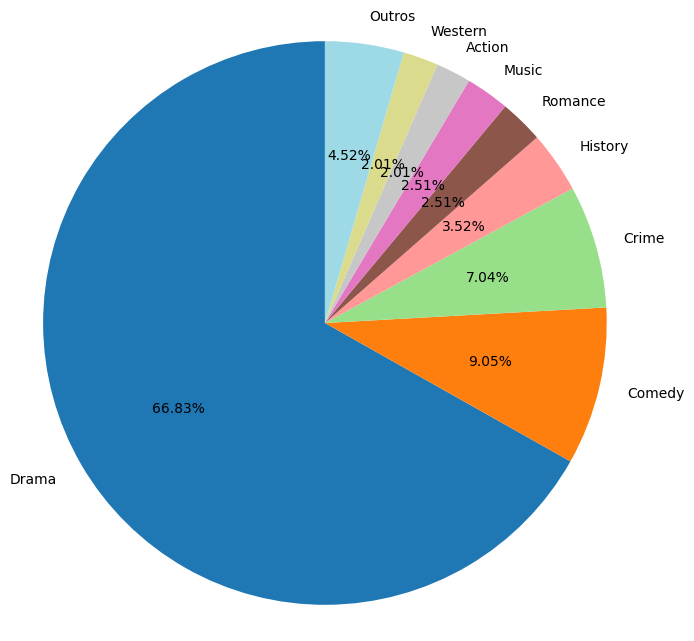

In [89]:
PizzaTopN(df_actors_leading_role_winner_genre_percentual, 8)

In [90]:
last_show_information(df_actors_leading_role_winner, "Genre")

,Genre,LastYear,YearsWithout
0,Drama,2024,0
1,Western,2015,9
2,Horror,1931/32,93
3,History,2018,6
4,Comedy,2016,8
5,Crime,2019,5
6,Music,2018,6
7,Adventure,1937,87
8,War,1970,54
9,Mystery,1941,83


##### País

###### Indicações

In [91]:
df_actors_in_leading_roles_country = df_Official.copy()
df_actors_in_leading_roles_country = df_actors_in_leading_roles_country[df_actors_in_leading_roles_country["CanonicalCategory"].isin(["ACTOR IN A LEADING ROLE", "ACTRESS IN A LEADING ROLE"])]
df_actors_in_leading_roles_country = df_actors_in_leading_roles_country[["CanonicalCategory", "Year", "Film", "Name", "Birth Country", "Birth Continent",  "Winner"]]
display(df_actors_in_leading_roles_country)

,CanonicalCategory,Year,Film,Name,Birth Country,Birth Continent,Winner
0,ACTOR IN A LEADING ROLE,1927/28,The Noose,Richard Barthelmess,[USA],[North America],False
1,ACTOR IN A LEADING ROLE,1927/28,The Patent Leather Kid,Richard Barthelmess,[USA],[North America],False
2,ACTOR IN A LEADING ROLE,1927/28,The Last Command,Emil Jannings,[Switzerland],[Europe],True
3,ACTOR IN A LEADING ROLE,1927/28,The Way of All Flesh,Emil Jannings,[Switzerland],[Europe],True
4,ACTRESS IN A LEADING ROLE,1927/28,A Ship Comes In,Louise Dresser,[USA],[North America],False
...,...,...,...,...,...,...,...
11886,ACTRESS IN A LEADING ROLE,2024,Wicked,Cynthia Erivo,[UK],[Europe],False
11887,ACTRESS IN A LEADING ROLE,2024,Emilia Pérez,Karla Sofía Gascón,[Spain],[Europe],False
11888,ACTRESS IN A LEADING ROLE,2024,Anora,Mikey Madison,[USA],[North America],True
11889,ACTRESS IN A LEADING ROLE,2024,The Substance,Demi Moore,[USA],[North America],False


In [92]:
df_exploded_actors_in_leading_roles = df_actors_in_leading_roles_country.copy().explode(["Birth Country", "Birth Continent"])
display(df_exploded_actors_in_leading_roles)

,CanonicalCategory,Year,Film,Name,Birth Country,Birth Continent,Winner
0,ACTOR IN A LEADING ROLE,1927/28,The Noose,Richard Barthelmess,USA,North America,False
1,ACTOR IN A LEADING ROLE,1927/28,The Patent Leather Kid,Richard Barthelmess,USA,North America,False
2,ACTOR IN A LEADING ROLE,1927/28,The Last Command,Emil Jannings,Switzerland,Europe,True
3,ACTOR IN A LEADING ROLE,1927/28,The Way of All Flesh,Emil Jannings,Switzerland,Europe,True
4,ACTRESS IN A LEADING ROLE,1927/28,A Ship Comes In,Louise Dresser,USA,North America,False
...,...,...,...,...,...,...,...
11886,ACTRESS IN A LEADING ROLE,2024,Wicked,Cynthia Erivo,UK,Europe,False
11887,ACTRESS IN A LEADING ROLE,2024,Emilia Pérez,Karla Sofía Gascón,Spain,Europe,False
11888,ACTRESS IN A LEADING ROLE,2024,Anora,Mikey Madison,USA,North America,True
11889,ACTRESS IN A LEADING ROLE,2024,The Substance,Demi Moore,USA,North America,False


In [93]:
df_actors_in_leading_roles_country_count = DataFrameInfoTotalCount(df_exploded_actors_in_leading_roles, "Birth Country")
display(df_actors_in_leading_roles_country_count)

,count
Birth Country,
USA,607
UK,192
France,23
Canada,19
Australia,13
Sweden,12
Italy,11
Japan,9
Ukraine,8


In [94]:
df_actors_in_leading_roles_country_percentual = DataFrameInfoPercentual(df_exploded_actors_in_leading_roles, "Birth Country")
display(df_actors_in_leading_roles_country_percentual)

,Birth Country,Percentual
0,USA,62.90
1,UK,19.90
2,France,2.38
3,Canada,1.97
4,Australia,1.35
5,Sweden,1.24
6,Italy,1.14
7,Japan,0.93
8,Ukraine,0.83
9,India,0.73


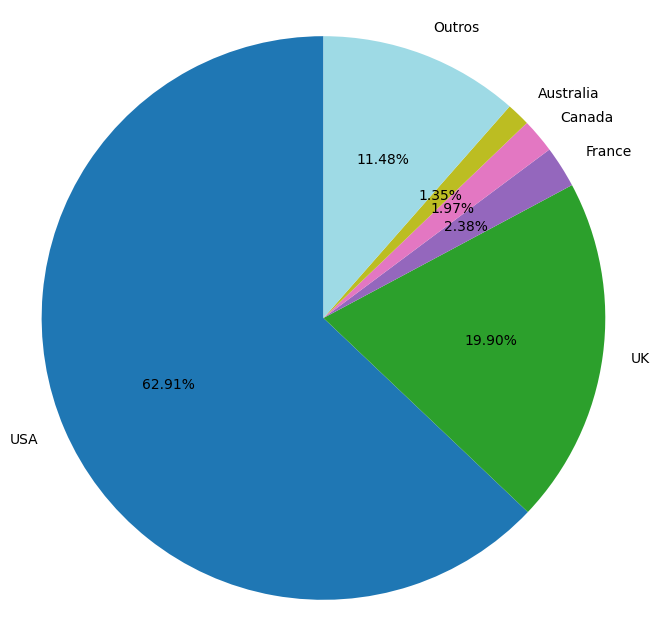

In [95]:
PizzaTopN(df_actors_in_leading_roles_country_percentual, 5)

In [96]:
df_actors_in_leading_roles_continent_count = DataFrameInfoTotalCount(df_exploded_actors_in_leading_roles, "Birth Continent")
display(df_actors_in_leading_roles_continent_count)

,count
Birth Continent,
North America,626
Europe,284
Asia,20
Oceania,16
Central America,10
Africa,5
South America,3


In [97]:
df_actors_in_leading_roles_continent_percentual = DataFrameInfoPercentual(df_exploded_actors_in_leading_roles, "Birth Continent")
display(df_actors_in_leading_roles_continent_percentual)

,Birth Continent,Percentual
0,North America,64.94
1,Europe,29.46
2,Asia,2.07
3,Oceania,1.66
4,Central America,1.04
5,Africa,0.52
6,South America,0.31


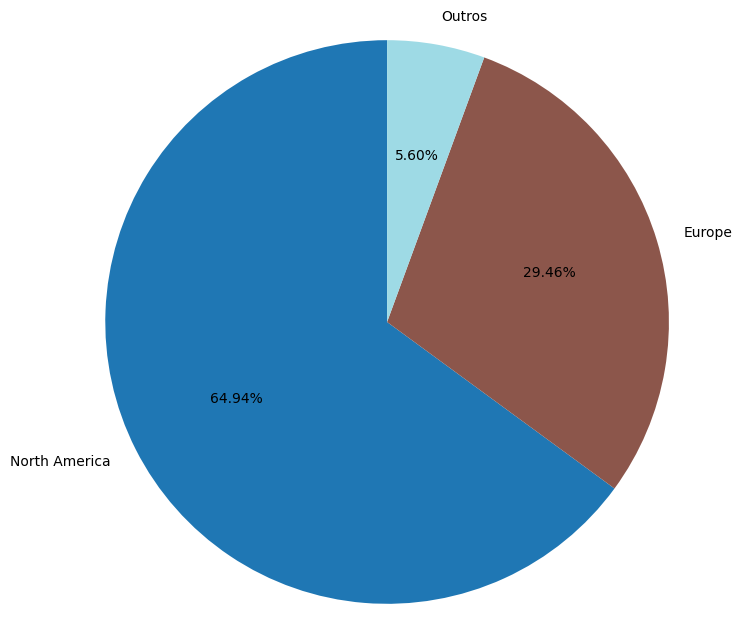

In [98]:
PizzaTopN(df_actors_in_leading_roles_continent_percentual, 2)

###### Vitória na categoria

In [99]:
df_actors_in_leading_country_winner = df_actors_in_leading_roles_country[df_actors_in_leading_roles_country["Winner"] == True]
display(df_actors_in_leading_country_winner)

,CanonicalCategory,Year,Film,Name,Birth Country,Birth Continent,Winner
2,ACTOR IN A LEADING ROLE,1927/28,The Last Command,Emil Jannings,[Switzerland],[Europe],True
3,ACTOR IN A LEADING ROLE,1927/28,The Way of All Flesh,Emil Jannings,[Switzerland],[Europe],True
5,ACTRESS IN A LEADING ROLE,1927/28,7th Heaven,Janet Gaynor,[USA],[North America],True
6,ACTRESS IN A LEADING ROLE,1927/28,Street Angel,Janet Gaynor,[USA],[North America],True
7,ACTRESS IN A LEADING ROLE,1927/28,Sunrise,Janet Gaynor,[USA],[North America],True
...,...,...,...,...,...,...,...
11617,ACTRESS IN A LEADING ROLE,2022,Everything Everywhere All at Once,Michelle Yeoh,[Malaysia],[Asia],True
11739,ACTOR IN A LEADING ROLE,2023,Oppenheimer,Cillian Murphy,[Ireland],[Europe],True
11750,ACTRESS IN A LEADING ROLE,2023,Poor Things,Emma Stone,[USA],[North America],True
11876,ACTOR IN A LEADING ROLE,2024,The Brutalist,Adrien Brody,[USA],[North America],True


In [100]:
df_exploded_actors_in_leading_roles_winner = df_actors_in_leading_country_winner.copy().explode(["Birth Country", "Birth Continent"])
display(df_exploded_actors_in_leading_roles_winner)

,CanonicalCategory,Year,Film,Name,Birth Country,Birth Continent,Winner
2,ACTOR IN A LEADING ROLE,1927/28,The Last Command,Emil Jannings,Switzerland,Europe,True
3,ACTOR IN A LEADING ROLE,1927/28,The Way of All Flesh,Emil Jannings,Switzerland,Europe,True
5,ACTRESS IN A LEADING ROLE,1927/28,7th Heaven,Janet Gaynor,USA,North America,True
6,ACTRESS IN A LEADING ROLE,1927/28,Street Angel,Janet Gaynor,USA,North America,True
7,ACTRESS IN A LEADING ROLE,1927/28,Sunrise,Janet Gaynor,USA,North America,True
...,...,...,...,...,...,...,...
11617,ACTRESS IN A LEADING ROLE,2022,Everything Everywhere All at Once,Michelle Yeoh,Malaysia,Asia,True
11739,ACTOR IN A LEADING ROLE,2023,Oppenheimer,Cillian Murphy,Ireland,Europe,True
11750,ACTRESS IN A LEADING ROLE,2023,Poor Things,Emma Stone,USA,North America,True
11876,ACTOR IN A LEADING ROLE,2024,The Brutalist,Adrien Brody,USA,North America,True


In [101]:
df_actors_in_leading_roles_country_winner_count = DataFrameInfoTotalCount(df_exploded_actors_in_leading_roles_winner, "Birth Country")
display(df_actors_in_leading_roles_country_winner_count)

,count
Birth Country,
USA,129
UK,34
France,3
Canada,3
India,3
Germany,3
Japan,3
Italy,3
Puerto Rico,2


In [102]:
df_actors_in_leading_roles_country__winner_percentual = DataFrameInfoPercentual(df_exploded_actors_in_leading_roles_winner, "Birth Country")
display(df_actors_in_leading_roles_country__winner_percentual)

,Birth Country,Percentual
0,USA,64.82
1,UK,17.09
2,France,1.51
3,Canada,1.51
4,India,1.51
5,Germany,1.51
6,Japan,1.51
7,Italy,1.51
8,Puerto Rico,1.01
9,Switzerland,1.01


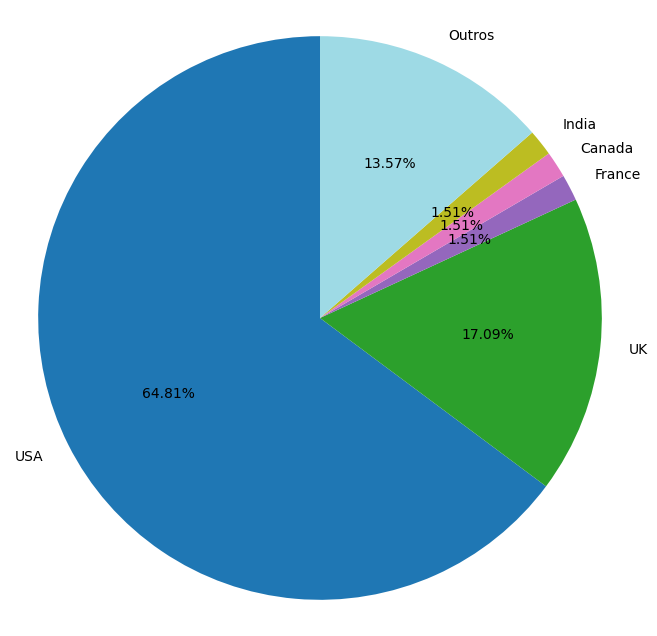

In [103]:
PizzaTopN(df_actors_in_leading_roles_country__winner_percentual, 5)

In [104]:
last_show_information(df_exploded_actors_in_leading_roles_winner, "Birth Country")

,Birth Country,LastYear,YearsWithout
0,Switzerland,1927/28,97
1,USA,2024,0
2,Canada,1930/31,94
3,UK,2020,4
4,France,2011,13
5,Ukraine,1936,88
6,Germany,1959,65
7,India,1965,59
8,Japan,1949,75
9,Hungary,1943,81


In [105]:
df_actors_in_leading_roles_continent_winner_count = DataFrameInfoTotalCount(df_exploded_actors_in_leading_roles_winner, "Birth Continent")
display(df_actors_in_leading_roles_continent_winner_count)

,count
Birth Continent,
North America,132
Europe,53
Asia,8
Oceania,3
Central America,2
Africa,1


In [106]:
df_actors_in_leading_roles_continent__winner_percentual = DataFrameInfoPercentual(df_exploded_actors_in_leading_roles_winner, "Birth Continent")
display(df_actors_in_leading_roles_continent__winner_percentual)

,Birth Continent,Percentual
0,North America,66.33
1,Europe,26.63
2,Asia,4.02
3,Oceania,1.51
4,Central America,1.01
5,Africa,0.50


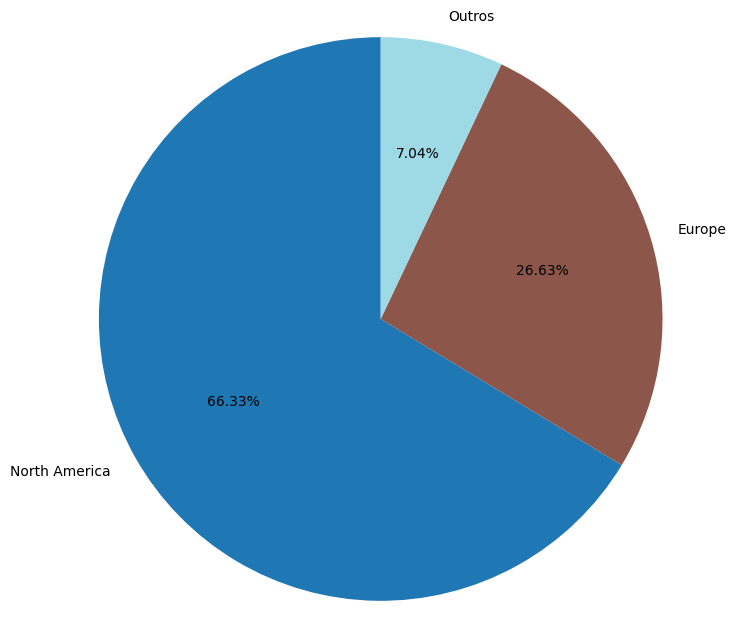

In [107]:
PizzaTopN(df_actors_in_leading_roles_continent__winner_percentual, 2)

#### Actors In Supporting Role

##### Genero

###### Indicações

In [108]:
df_actors_supporting_role = df_Official.copy()
df_actors_supporting_role = df_actors_supporting_role[df_actors_supporting_role["CanonicalCategory"].isin(["ACTOR IN A SUPPORTING ROLE", "ACTRESS IN A SUPPORTING ROLE"])]
df_actors_supporting_role = df_actors_supporting_role[["CanonicalCategory", "Year", "Film", "Genre", "Nominees", "Winner"]]
display(df_actors_supporting_role)

,CanonicalCategory,Year,Film,Genre,Nominees,Winner
464,ACTOR IN A SUPPORTING ROLE,1936,My Man Godfrey,Comedy,Mischa Auer,False
465,ACTOR IN A SUPPORTING ROLE,1936,Come and Get It,Drama,Walter Brennan,True
466,ACTOR IN A SUPPORTING ROLE,1936,Pigskin Parade,Comedy,Stuart Erwin,False
467,ACTOR IN A SUPPORTING ROLE,1936,Romeo and Juliet,Drama,Basil Rathbone,False
468,ACTOR IN A SUPPORTING ROLE,1936,The General Died at Dawn,Drama,Akim Tamiroff,False
...,...,...,...,...,...,...
11891,ACTRESS IN A SUPPORTING ROLE,2024,A Complete Unknown,Drama,Monica Barbaro,False
11892,ACTRESS IN A SUPPORTING ROLE,2024,Wicked,Drama,Ariana Grande,False
11893,ACTRESS IN A SUPPORTING ROLE,2024,The Brutalist,Drama,Felicity Jones,False
11894,ACTRESS IN A SUPPORTING ROLE,2024,Conclave,Drama,Isabella Rossellini,False


In [109]:
DataFrameInfoTotalCount(df_actors_supporting_role, "Genre")

,count
Genre,
Drama,531
Comedy,147
Crime,59
Action,23
Thriller,20
Adventure,20
Romance,20
History,13
Western,11


In [110]:
df_actors_supporting_genre_percentual = DataFrameInfoPercentual(df_actors_supporting_role, "Genre")
display(df_actors_supporting_genre_percentual)

,Genre,Percentual
0,Drama,59.66
1,Comedy,16.52
2,Crime,6.63
3,Action,2.58
4,Thriller,2.25
5,Adventure,2.25
6,Romance,2.25
7,History,1.46
8,Western,1.24
9,War,1.24


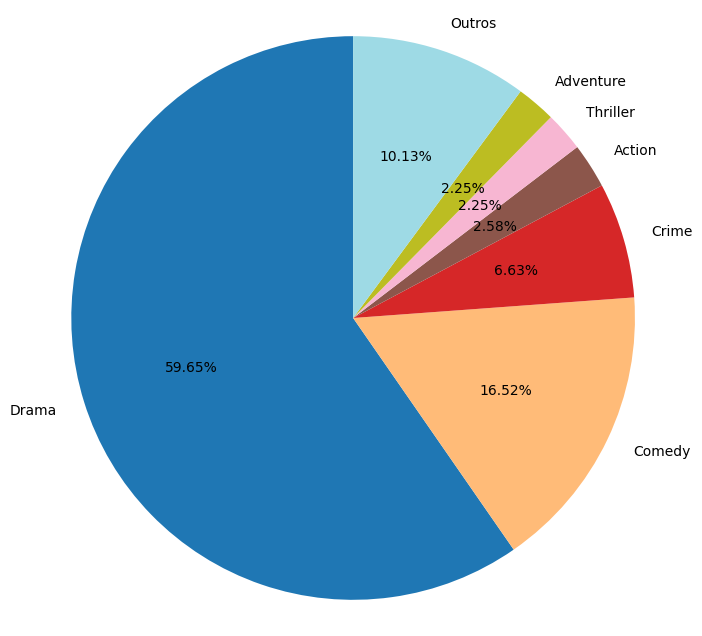

In [111]:
PizzaTopN(df_actors_supporting_genre_percentual, 6)

In [112]:
df_actors_supporting_genre_count = show_raw_data_count_for_year(df_actors_supporting_role, "Genre")
display(df_actors_supporting_genre_count)

,Year,Genre,Count
0,1936,Action,0
1,1936,Adventure,0
2,1936,Comedy,3
3,1936,Crime,0
4,1936,Drama,7
...,...,...,...
1419,2024,Romance,0
1420,2024,Science Fiction,0
1421,2024,Thriller,0
1422,2024,War,0


In [113]:
df_actors_supporting_genre_data_analytics = calculate_basics_analitics(df_actors_supporting_genre_count, "Genre")
display(df_actors_supporting_genre_data_analytics)

,Genre,Média,Mediana,Moda,Amplitude,Desvio
0,Action,0.25,0.0,[0],4,0.683043
1,Adventure,0.22,0.0,[0],3,0.494350
2,Comedy,1.65,1.0,[1],6,1.470166
3,Crime,0.66,0.0,[0],4,0.964646
4,Drama,5.96,6.0,[7],9,1.879612
5,Family,0.04,0.0,[0],3,0.334056
6,Fantasy,0.08,0.0,[0],2,0.324753
7,History,0.14,0.0,[0],2,0.414251
8,Horror,0.06,0.0,[0],2,0.293790
9,Music,0.07,0.0,[0],2,0.309865


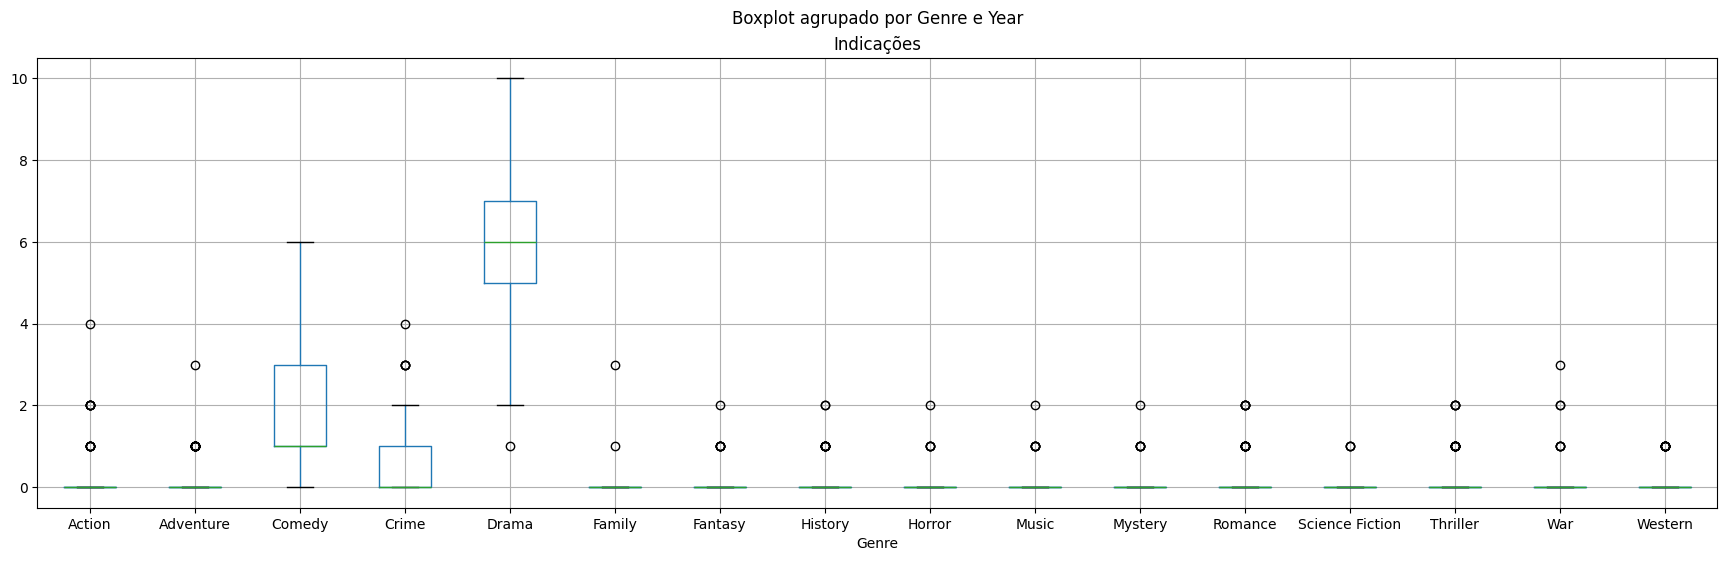

In [114]:
BoxplotByCollumForYears(df_actors_supporting_role, "Genre")

###### Vitórias na categoria

In [115]:
df_actors_supporting_role_winner = df_actors_supporting_role[df_actors_supporting_role["Winner"] == True]
display(df_actors_supporting_role_winner)

,CanonicalCategory,Year,Film,Genre,Nominees,Winner
465,ACTOR IN A SUPPORTING ROLE,1936,Come and Get It,Drama,Walter Brennan,True
478,ACTRESS IN A SUPPORTING ROLE,1936,Anthony Adverse,Drama,Gale Sondergaard,True
580,ACTOR IN A SUPPORTING ROLE,1937,The Life of Emile Zola,Drama,Joseph Schildkraut,True
588,ACTRESS IN A SUPPORTING ROLE,1937,In Old Chicago,Drama,Alice Brady,True
712,ACTOR IN A SUPPORTING ROLE,1938,Kentucky,Drama,Walter Brennan,True
...,...,...,...,...,...,...
11621,ACTRESS IN A SUPPORTING ROLE,2022,Everything Everywhere All at Once,Action,Jamie Lee Curtis,True
11743,ACTOR IN A SUPPORTING ROLE,2023,Oppenheimer,Drama,Robert Downey Jr.,True
11755,ACTRESS IN A SUPPORTING ROLE,2023,The Holdovers,Comedy,Da'Vine Joy Randolph,True
11882,ACTOR IN A SUPPORTING ROLE,2024,A Real Pain,Comedy,Kieran Culkin,True


In [116]:
DataFrameInfoTotalCount(df_actors_supporting_role_winner, "Genre")

,count
Genre,
Drama,105
Comedy,36
Crime,10
War,5
Action,5
Romance,5
Western,3
History,3
Thriller,3


In [117]:
df_actors_supporting_role_winner_genre_percentual = DataFrameInfoPercentual(df_actors_supporting_role_winner, "Genre")
display(df_actors_supporting_role_winner_genre_percentual)

,Genre,Percentual
0,Drama,58.99
1,Comedy,20.22
2,Crime,5.62
3,War,2.81
4,Action,2.81
5,Romance,2.81
6,Western,1.69
7,History,1.69
8,Thriller,1.69
9,Adventure,0.56


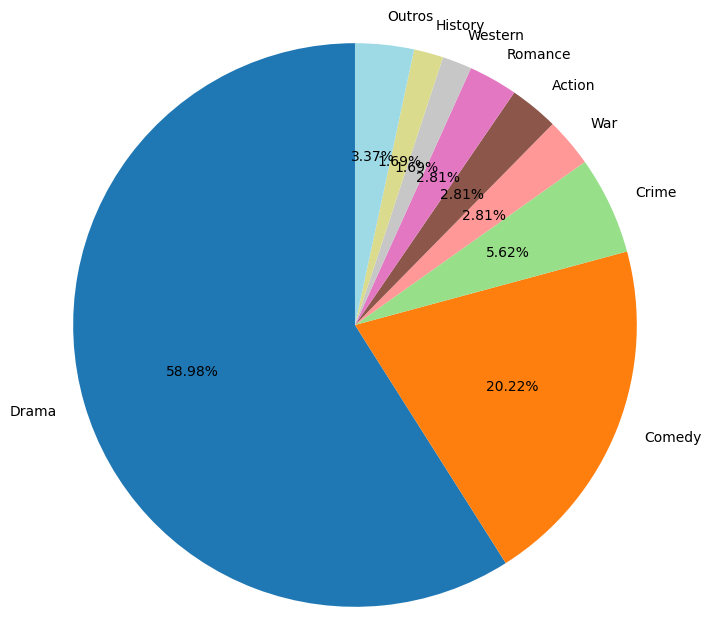

In [118]:
PizzaTopN(df_actors_supporting_role_winner_genre_percentual, 8)

In [119]:
last_show_information(df_actors_supporting_role_winner, "Genre")

,Genre,LastYear,YearsWithout
0,Drama,2024,0
1,Western,1992,32
2,Crime,2017,7
3,Comedy,2024,0
4,War,2003,21
5,Adventure,1948,76
6,History,1960,64
7,Romance,2018,6
8,Action,2022,2
9,Music,1972,52


##### País

###### Indicações

In [120]:
df_supporting_role_country = df_Official.copy()
df_supporting_role_country = df_supporting_role_country[df_supporting_role_country["CanonicalCategory"].isin(["ACTOR IN A SUPPORTING ROLE", "ACTRESS IN A SUPPORTING ROLE"])]
df_supporting_role_country = df_supporting_role_country[["CanonicalCategory", "Year", "Film", "Name", "Birth Country", "Birth Continent",  "Winner"]]
display(df_supporting_role_country)

,CanonicalCategory,Year,Film,Name,Birth Country,Birth Continent,Winner
464,ACTOR IN A SUPPORTING ROLE,1936,My Man Godfrey,Mischa Auer,[Russia],[Europe],False
465,ACTOR IN A SUPPORTING ROLE,1936,Come and Get It,Walter Brennan,[USA],[North America],True
466,ACTOR IN A SUPPORTING ROLE,1936,Pigskin Parade,Stuart Erwin,[USA],[North America],False
467,ACTOR IN A SUPPORTING ROLE,1936,Romeo and Juliet,Basil Rathbone,[South African Republic],[Africa],False
468,ACTOR IN A SUPPORTING ROLE,1936,The General Died at Dawn,Akim Tamiroff,[Republic of Georgia],[Europe],False
...,...,...,...,...,...,...,...
11891,ACTRESS IN A SUPPORTING ROLE,2024,A Complete Unknown,Monica Barbaro,[USA],[North America],False
11892,ACTRESS IN A SUPPORTING ROLE,2024,Wicked,Ariana Grande,[USA],[North America],False
11893,ACTRESS IN A SUPPORTING ROLE,2024,The Brutalist,Felicity Jones,[UK],[Europe],False
11894,ACTRESS IN A SUPPORTING ROLE,2024,Conclave,Isabella Rossellini,[Italy],[Europe],False


In [121]:
df_exploded_supporting_role = df_supporting_role_country.copy().explode(["Birth Country", "Birth Continent"])
display(df_exploded_supporting_role)

,CanonicalCategory,Year,Film,Name,Birth Country,Birth Continent,Winner
464,ACTOR IN A SUPPORTING ROLE,1936,My Man Godfrey,Mischa Auer,Russia,Europe,False
465,ACTOR IN A SUPPORTING ROLE,1936,Come and Get It,Walter Brennan,USA,North America,True
466,ACTOR IN A SUPPORTING ROLE,1936,Pigskin Parade,Stuart Erwin,USA,North America,False
467,ACTOR IN A SUPPORTING ROLE,1936,Romeo and Juliet,Basil Rathbone,South African Republic,Africa,False
468,ACTOR IN A SUPPORTING ROLE,1936,The General Died at Dawn,Akim Tamiroff,Republic of Georgia,Europe,False
...,...,...,...,...,...,...,...
11891,ACTRESS IN A SUPPORTING ROLE,2024,A Complete Unknown,Monica Barbaro,USA,North America,False
11892,ACTRESS IN A SUPPORTING ROLE,2024,Wicked,Ariana Grande,USA,North America,False
11893,ACTRESS IN A SUPPORTING ROLE,2024,The Brutalist,Felicity Jones,UK,Europe,False
11894,ACTRESS IN A SUPPORTING ROLE,2024,Conclave,Isabella Rossellini,Italy,Europe,False


In [122]:
df_supporting_country_count = DataFrameInfoTotalCount(df_exploded_supporting_role, "Birth Country")
display(df_supporting_country_count)

,count
Birth Country,
USA,621
UK,139
Canada,18
Australia,15
Italy,11
Austria,9
Ireland,8
Russia,7
Japan,6


In [123]:
df_supporting_country_percentual = DataFrameInfoPercentual(df_exploded_supporting_role, "Birth Country")
display(df_supporting_country_percentual)

,Birth Country,Percentual
0,USA,69.78
1,UK,15.62
2,Canada,2.02
3,Australia,1.69
4,Italy,1.24
5,Austria,1.01
6,Ireland,0.90
7,Russia,0.79
8,Japan,0.67
9,Mexico,0.67


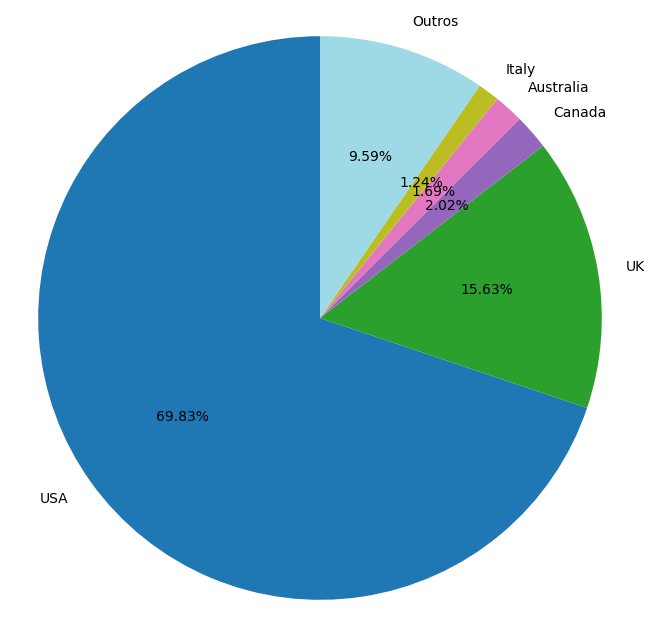

In [124]:
PizzaTopN(df_supporting_country_percentual, 5)

In [125]:
df_supporting_continent_count = DataFrameInfoTotalCount(df_exploded_supporting_role, "Birth Continent")
display(df_supporting_continent_count)

,count
Birth Continent,
North America,639
Europe,197
Oceania,16
Asia,13
Central America,12
Africa,10
South America,2


In [126]:
df_supporting_continent_percentual = DataFrameInfoPercentual(df_exploded_supporting_role, "Birth Continent")
display(df_supporting_continent_percentual)

,Birth Continent,Percentual
0,North America,71.88
1,Europe,22.16
2,Oceania,1.80
3,Asia,1.46
4,Central America,1.35
5,Africa,1.12
6,South America,0.22


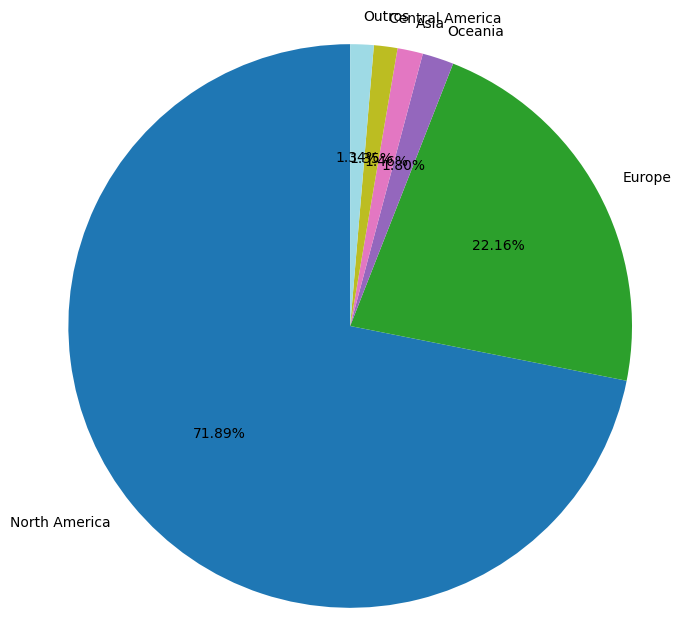

In [127]:
PizzaTopN(df_supporting_continent_percentual, 5)

###### Vitórias na categoria

In [128]:
df_supporting_roles_country_winner = df_supporting_role_country[df_supporting_role_country["Winner"] == True]
display(df_supporting_roles_country_winner)

,CanonicalCategory,Year,Film,Name,Birth Country,Birth Continent,Winner
465,ACTOR IN A SUPPORTING ROLE,1936,Come and Get It,Walter Brennan,[USA],[North America],True
478,ACTRESS IN A SUPPORTING ROLE,1936,Anthony Adverse,Gale Sondergaard,[USA],[North America],True
580,ACTOR IN A SUPPORTING ROLE,1937,The Life of Emile Zola,Joseph Schildkraut,[Austria],[Europe],True
588,ACTRESS IN A SUPPORTING ROLE,1937,In Old Chicago,Alice Brady,[USA],[North America],True
712,ACTOR IN A SUPPORTING ROLE,1938,Kentucky,Walter Brennan,[USA],[North America],True
...,...,...,...,...,...,...,...
11621,ACTRESS IN A SUPPORTING ROLE,2022,Everything Everywhere All at Once,Jamie Lee Curtis,[USA],[North America],True
11743,ACTOR IN A SUPPORTING ROLE,2023,Oppenheimer,Robert Downey Jr.,[USA],[North America],True
11755,ACTRESS IN A SUPPORTING ROLE,2023,The Holdovers,Da'Vine Joy Randolph,[USA],[North America],True
11882,ACTOR IN A SUPPORTING ROLE,2024,A Real Pain,Kieran Culkin,[USA],[North America],True


In [129]:
df_exploded_supporting_roles_winner = df_supporting_roles_country_winner.copy().explode(["Birth Country", "Birth Continent"])
display(df_exploded_supporting_roles_winner)

,CanonicalCategory,Year,Film,Name,Birth Country,Birth Continent,Winner
465,ACTOR IN A SUPPORTING ROLE,1936,Come and Get It,Walter Brennan,USA,North America,True
478,ACTRESS IN A SUPPORTING ROLE,1936,Anthony Adverse,Gale Sondergaard,USA,North America,True
580,ACTOR IN A SUPPORTING ROLE,1937,The Life of Emile Zola,Joseph Schildkraut,Austria,Europe,True
588,ACTRESS IN A SUPPORTING ROLE,1937,In Old Chicago,Alice Brady,USA,North America,True
712,ACTOR IN A SUPPORTING ROLE,1938,Kentucky,Walter Brennan,USA,North America,True
...,...,...,...,...,...,...,...
11621,ACTRESS IN A SUPPORTING ROLE,2022,Everything Everywhere All at Once,Jamie Lee Curtis,USA,North America,True
11743,ACTOR IN A SUPPORTING ROLE,2023,Oppenheimer,Robert Downey Jr.,USA,North America,True
11755,ACTRESS IN A SUPPORTING ROLE,2023,The Holdovers,Da'Vine Joy Randolph,USA,North America,True
11882,ACTOR IN A SUPPORTING ROLE,2024,A Real Pain,Kieran Culkin,USA,North America,True


In [130]:
df_supporting_role_country_winner_count = DataFrameInfoTotalCount(df_exploded_supporting_roles_winner, "Birth Country")
display(df_supporting_role_country_winner_count)

,count
Birth Country,
USA,126
UK,23
Canada,4
Austria,3
Mexico,3
Ireland,2
Puerto Rico,2
Russia,2
Australia,2


In [131]:
df_supporting_role_country__winner_percentual = DataFrameInfoPercentual(df_exploded_supporting_roles_winner, "Birth Country")
display(df_supporting_role_country__winner_percentual)

,Birth Country,Percentual
0,USA,70.79
1,UK,12.92
2,Canada,2.25
3,Austria,1.69
4,Mexico,1.69
5,Ireland,1.12
6,Puerto Rico,1.12
7,Russia,1.12
8,Australia,1.12
9,Sweden,1.12


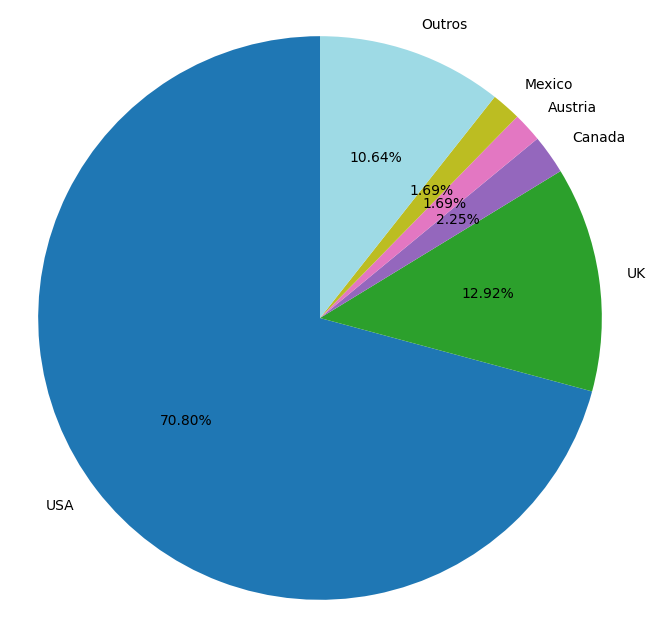

In [132]:
PizzaTopN(df_supporting_role_country__winner_percentual, 5)

In [133]:
last_show_information(df_exploded_supporting_roles_winner, "Birth Country")

,Birth Country,LastYear,YearsWithout
0,USA,2024,0
1,Austria,2012,12
2,UK,2020,4
3,Greece,1943,81
4,Ireland,1989,35
5,Canada,2011,13
6,Russia,1964,60
7,Mexico,2013,11
8,Japan,1957,67
9,Puerto Rico,2000,24


In [134]:
df_supporting_role_continent_winner_count = DataFrameInfoTotalCount(df_exploded_supporting_roles_winner, "Birth Continent")
display(df_supporting_role_continent_winner_count)

,count
Birth Continent,
North America,130
Europe,37
Central America,5
Asia,4
Oceania,2


In [135]:
df_supporting_role_continent__winner_percentual = DataFrameInfoPercentual(df_exploded_supporting_roles_winner, "Birth Continent")
display(df_supporting_role_continent__winner_percentual)

,Birth Continent,Percentual
0,North America,73.03
1,Europe,20.79
2,Central America,2.81
3,Asia,2.25
4,Oceania,1.12


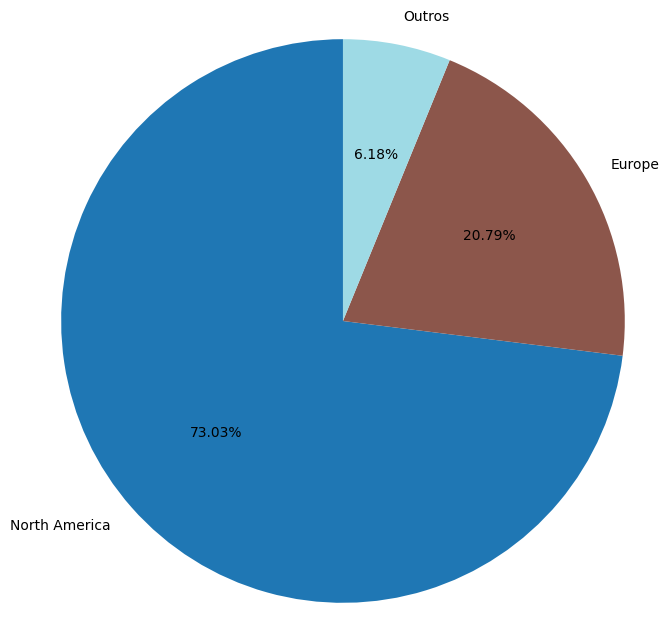

In [136]:
PizzaTopN(df_supporting_role_continent__winner_percentual, 2)

#### Directing

##### Genero

###### Indicações

In [137]:
df_directing = df_Official.copy()
df_directing = df_directing[df_directing["CanonicalCategory"].isin(["DIRECTING"])]
df_directing = df_directing[["CanonicalCategory", "Year", "Film", "Genre", "Nominees", "Winner"]]
display(df_directing)

,CanonicalCategory,Year,Film,Genre,Nominees,Winner
64,DIRECTING,1928/29,Madame X,Drama,Lionel Barrymore,False
65,DIRECTING,1928/29,The Broadway Melody,Music,Harry Beaumont,False
66,DIRECTING,1928/29,In Old Arizona,Western,Irving Cummings,False
67,DIRECTING,1928/29,The Divine Lady,Drama,Frank Lloyd,True
68,DIRECTING,1928/29,Drag,Crime,Frank Lloyd,False
...,...,...,...,...,...,...
11916,DIRECTING,2024,Anora,Drama,Sean Baker,True
11917,DIRECTING,2024,The Brutalist,Drama,Brady Corbet,False
11918,DIRECTING,2024,A Complete Unknown,Drama,James Mangold,False
11919,DIRECTING,2024,Emilia Pérez,Drama,Jacques Audiard,False


In [138]:
DataFrameInfoTotalCount(df_directing, "Genre")

,count
Genre,
Drama,268
Comedy,60
Crime,33
Adventure,17
Thriller,15
Romance,12
War,12
Action,12
History,9


In [139]:
df_directing_genre_percentual = DataFrameInfoPercentual(df_directing, "Genre")

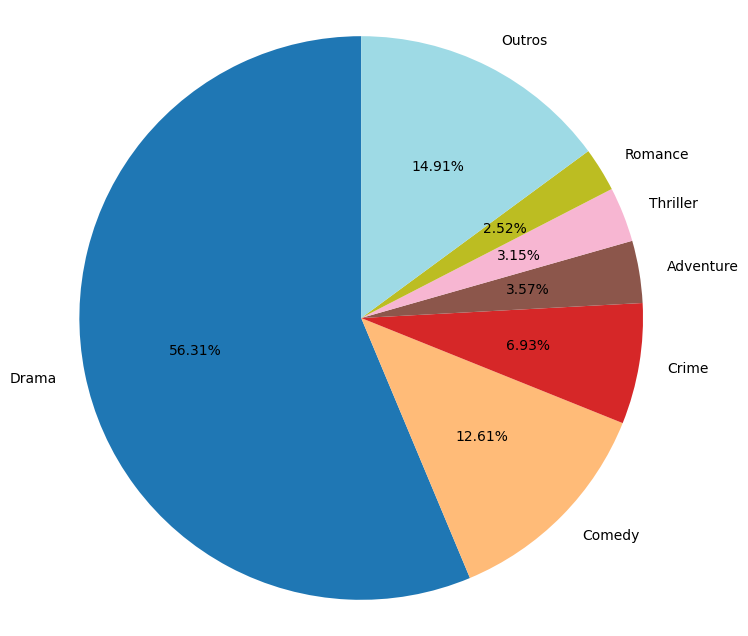

In [140]:
PizzaTopN(df_directing_genre_percentual, 6)

In [141]:
df_directing_genre_count = show_raw_data_count_for_year(df_directing, "Genre")
display(df_directing_genre_count)

,Year,Genre,Count
0,1928/29,Action,0
1,1928/29,Adventure,0
2,1928/29,Animation,0
3,1928/29,Comedy,0
4,1928/29,Crime,1
...,...,...,...
1627,2024,Romance,0
1628,2024,Science Fiction,0
1629,2024,Thriller,0
1630,2024,War,0


In [142]:
df_actors_leading_genre_data_analytics = calculate_basics_analitics(df_directing_genre_count, "Genre")
display(df_actors_leading_genre_data_analytics)

,Genre,Média,Mediana,Moda,Amplitude,Desvio
0,Action,0.12,0.0,[0],1,0.332455
1,Adventure,0.17,0.0,[0],3,0.481113
2,Animation,0.01,0.0,[0],1,0.102062
3,Comedy,0.62,1.0,[0],3,0.699624
4,Crime,0.34,0.0,[0],3,0.629588
5,Documentary,0.01,0.0,[0],1,0.102062
6,Drama,2.79,3.0,[3],5,1.094644
7,Fantasy,0.05,0.0,[0],1,0.223361
8,History,0.09,0.0,[0],1,0.293011
9,Horror,0.03,0.0,[0],1,0.174906


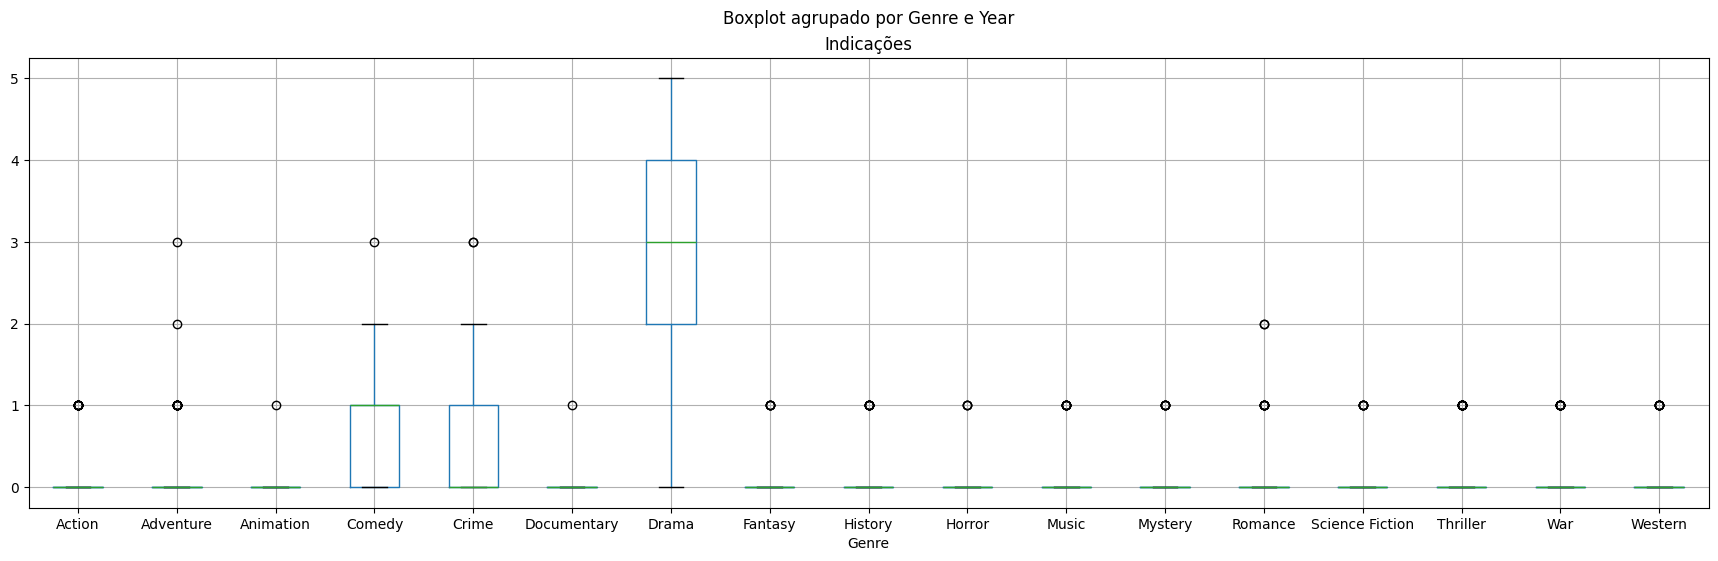

In [143]:
BoxplotByCollumForYears(df_directing, "Genre")

###### Vitórias na Categoria

In [144]:
df_directing_winner = df_directing[df_directing["Winner"] == True]
display(df_directing_winner)

,CanonicalCategory,Year,Film,Genre,Nominees,Winner
67,DIRECTING,1928/29,The Divine Lady,Drama,Frank Lloyd,True
116,DIRECTING,1929/30,All Quiet on the Western Front,War,Lewis Milestone,True
157,DIRECTING,1930/31,Skippy,Drama,Norman Taurog,True
195,DIRECTING,1931/32,Bad Girl,Drama,Frank Borzage,True
260,DIRECTING,1932/33,Cavalcade,Drama,Frank Lloyd,True
...,...,...,...,...,...,...
11397,DIRECTING,2020,Nomadland,Drama,Chloé Zhao,True
11517,DIRECTING,2021,The Power of the Dog,Drama,Jane Campion,True
11639,DIRECTING,2022,Everything Everywhere All at Once,Action,"Daniel Kwan, Daniel Scheinert",True
11773,DIRECTING,2023,Oppenheimer,Drama,Christopher Nolan,True


In [145]:
DataFrameInfoTotalCount(df_directing_winner, "Genre")

,count
Genre,
Drama,56
Comedy,13
Adventure,5
War,4
Crime,4
Action,3
History,3
Romance,2
Western,2


In [146]:
df_directing_winner_genre_percentual = DataFrameInfoPercentual(df_directing_winner, "Genre")
display(df_directing_winner_genre_percentual)

,Genre,Percentual
0,Drama,58.33
1,Comedy,13.54
2,Adventure,5.21
3,War,4.17
4,Crime,4.17
5,Action,3.12
6,History,3.12
7,Romance,2.08
8,Western,2.08
9,Animation,1.04


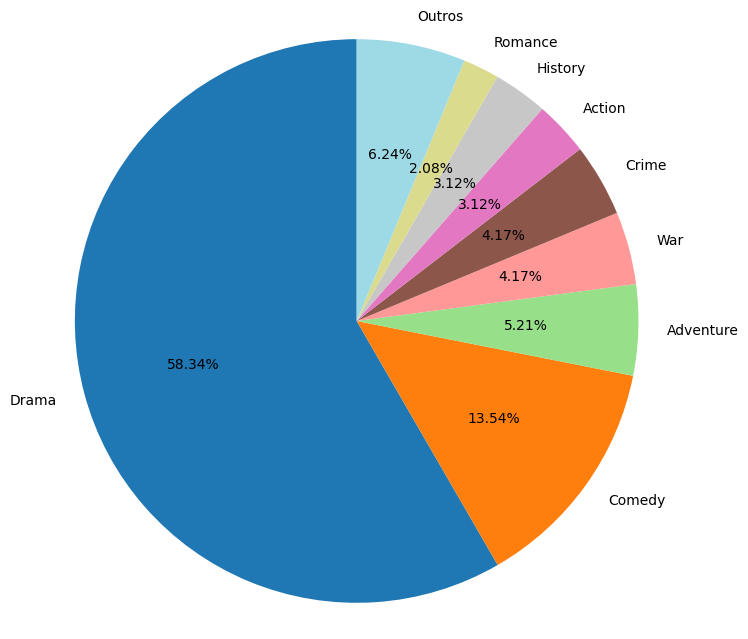

In [147]:
PizzaTopN(df_directing_winner_genre_percentual, 8)

In [148]:
last_show_information(df_directing_winner, "Genre")

,Genre,LastYear,YearsWithout
0,Drama,2024,0
1,War,1998,26
2,Comedy,2019,5
3,Crime,2007,17
4,Adventure,2012,12
5,Romance,1952,72
6,Animation,1951,73
7,History,1985,39
8,Action,2022,2
9,Music,1972,52


##### Pais

###### Indicações

In [149]:
df_directign_country = df_Official.copy()
df_directign_country = df_directign_country[df_directign_country["CanonicalCategory"].isin(["DIRECTING"])]
df_directign_country = df_directign_country[["CanonicalCategory", "Year", "Film", "Name", "Birth Country", "Birth Continent",  "Winner"]]
display(df_directign_country)

,CanonicalCategory,Year,Film,Name,Birth Country,Birth Continent,Winner
64,DIRECTING,1928/29,Madame X,Lionel Barrymore,[USA],[North America],False
65,DIRECTING,1928/29,The Broadway Melody,Harry Beaumont,[USA],[North America],False
66,DIRECTING,1928/29,In Old Arizona,Irving Cummings,[USA],[North America],False
67,DIRECTING,1928/29,The Divine Lady,Frank Lloyd,[Scotland],[Europe],True
68,DIRECTING,1928/29,Drag,Frank Lloyd,[Scotland],[Europe],False
...,...,...,...,...,...,...,...
11916,DIRECTING,2024,Anora,Sean Baker,[USA],[North America],True
11917,DIRECTING,2024,The Brutalist,Brady Corbet,[USA],[North America],False
11918,DIRECTING,2024,A Complete Unknown,James Mangold,[USA],[North America],False
11919,DIRECTING,2024,Emilia Pérez,Jacques Audiard,[France],[Europe],False


In [150]:
df_exploded_directing = df_directign_country.copy().explode(["Birth Country", "Birth Continent"])
display(df_exploded_directing)

,CanonicalCategory,Year,Film,Name,Birth Country,Birth Continent,Winner
64,DIRECTING,1928/29,Madame X,Lionel Barrymore,USA,North America,False
65,DIRECTING,1928/29,The Broadway Melody,Harry Beaumont,USA,North America,False
66,DIRECTING,1928/29,In Old Arizona,Irving Cummings,USA,North America,False
67,DIRECTING,1928/29,The Divine Lady,Frank Lloyd,Scotland,Europe,True
68,DIRECTING,1928/29,Drag,Frank Lloyd,Scotland,Europe,False
...,...,...,...,...,...,...,...
11916,DIRECTING,2024,Anora,Sean Baker,USA,North America,True
11917,DIRECTING,2024,The Brutalist,Brady Corbet,USA,North America,False
11918,DIRECTING,2024,A Complete Unknown,James Mangold,USA,North America,False
11919,DIRECTING,2024,Emilia Pérez,Jacques Audiard,France,Europe,False


In [151]:
df_directign_country_count = DataFrameInfoTotalCount(df_exploded_directing, "Birth Country")
display(df_directign_country_count)

,count
Birth Country,
USA,253
UK,66
France,24
Italy,18
Canada,13
Germany,12
Austria-Hungary,10
Poland,9
Australia,8


In [152]:
df_directign_country_percentual = DataFrameInfoPercentual(df_exploded_directing, "Birth Country")
display(df_directign_country_percentual)

,Birth Country,Percentual
0,USA,52.60
1,UK,13.72
2,France,4.99
3,Italy,3.74
4,Canada,2.70
5,Germany,2.49
6,Austria-Hungary,2.08
7,Poland,1.87
8,Australia,1.66
9,Sweden,1.46


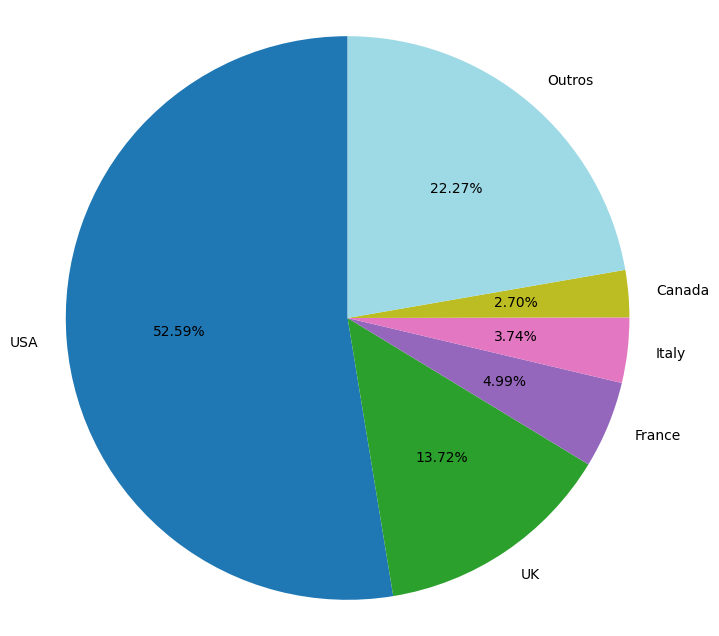

In [153]:
PizzaTopN(df_directign_country_percentual, 5)

In [154]:
df_directign_continent_count = DataFrameInfoTotalCount(df_exploded_directing, "Birth Continent")
display(df_directign_continent_count)

,count
Birth Continent,
North America,266
Europe,175
Asia,18
Oceania,12
Central America,6
South America,2
Africa,2


In [155]:
df_directign_continent_percentual = DataFrameInfoPercentual(df_exploded_directing, "Birth Continent")
display(df_directign_continent_percentual)

,Birth Continent,Percentual
0,North America,55.30
1,Europe,36.38
2,Asia,3.74
3,Oceania,2.49
4,Central America,1.25
5,South America,0.42
6,Africa,0.42


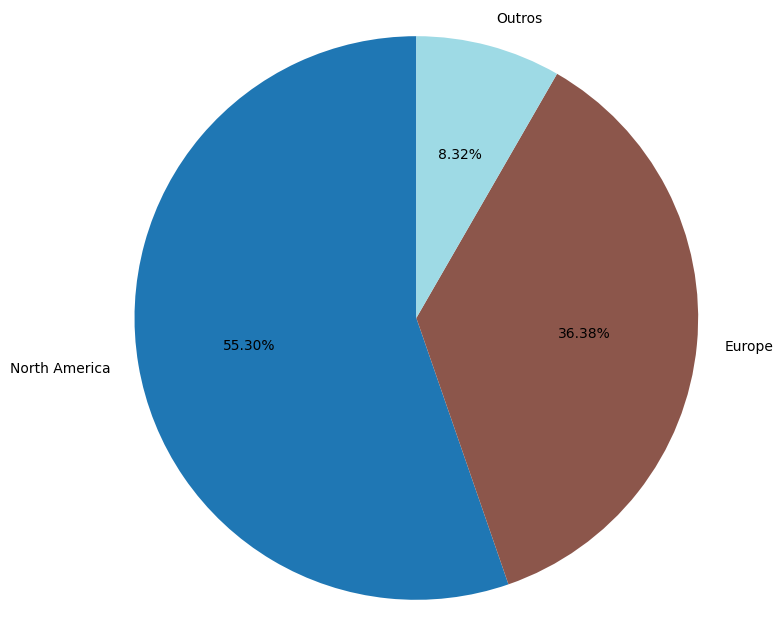

In [156]:
PizzaTopN(df_directign_continent_percentual, 2)

###### Vitórias na Categoria

In [157]:
df_directign_country_winner = df_directign_country[df_directign_country["Winner"] == True]
display(df_directign_country_winner)

,CanonicalCategory,Year,Film,Name,Birth Country,Birth Continent,Winner
67,DIRECTING,1928/29,The Divine Lady,Frank Lloyd,[Scotland],[Europe],True
116,DIRECTING,1929/30,All Quiet on the Western Front,Lewis Milestone,[Russian Empire],[Europe],True
157,DIRECTING,1930/31,Skippy,Norman Taurog,[USA],[North America],True
195,DIRECTING,1931/32,Bad Girl,Frank Borzage,[USA],[North America],True
260,DIRECTING,1932/33,Cavalcade,Frank Lloyd,[Scotland],[Europe],True
...,...,...,...,...,...,...,...
11397,DIRECTING,2020,Nomadland,Chloé Zhao,[China],[Asia],True
11517,DIRECTING,2021,The Power of the Dog,Jane Campion,[New Zealand],[Oceania],True
11639,DIRECTING,2022,Everything Everywhere All at Once,Daniel Kwan and Daniel Scheinert,"[USA, USA]","[North America, North America]",True
11773,DIRECTING,2023,Oppenheimer,Christopher Nolan,[UK],[Europe],True


In [158]:
df_exploded_directing_winner = df_directign_country_winner.copy().explode(["Birth Country", "Birth Continent"])
display(df_exploded_directing_winner)

,CanonicalCategory,Year,Film,Name,Birth Country,Birth Continent,Winner
67,DIRECTING,1928/29,The Divine Lady,Frank Lloyd,Scotland,Europe,True
116,DIRECTING,1929/30,All Quiet on the Western Front,Lewis Milestone,Russian Empire,Europe,True
157,DIRECTING,1930/31,Skippy,Norman Taurog,USA,North America,True
195,DIRECTING,1931/32,Bad Girl,Frank Borzage,USA,North America,True
260,DIRECTING,1932/33,Cavalcade,Frank Lloyd,Scotland,Europe,True
...,...,...,...,...,...,...,...
11517,DIRECTING,2021,The Power of the Dog,Jane Campion,New Zealand,Oceania,True
11639,DIRECTING,2022,Everything Everywhere All at Once,Daniel Kwan and Daniel Scheinert,USA,North America,True
11639,DIRECTING,2022,Everything Everywhere All at Once,Daniel Kwan and Daniel Scheinert,USA,North America,True
11773,DIRECTING,2023,Oppenheimer,Christopher Nolan,UK,Europe,True


In [159]:
df_directign_country_winner_count = DataFrameInfoTotalCount(df_exploded_directing_winner, "Birth Country")
display(df_directign_country_winner_count)

,count
Birth Country,
USA,53
UK,11
France,5
Mexico,5
Italy,4
Taiwan,2
Scotland,2
Poland,2
Turkey,2


In [160]:
df_directign_country__winner_percentual = DataFrameInfoPercentual(df_exploded_directing_winner, "Birth Country")
display(df_directign_country__winner_percentual)

,Birth Country,Percentual
0,USA,53.54
1,UK,11.11
2,France,5.05
3,Mexico,5.05
4,Italy,4.04
5,Taiwan,2.02
6,Scotland,2.02
7,Poland,2.02
8,Turkey,2.02
9,Czech Republic,2.02


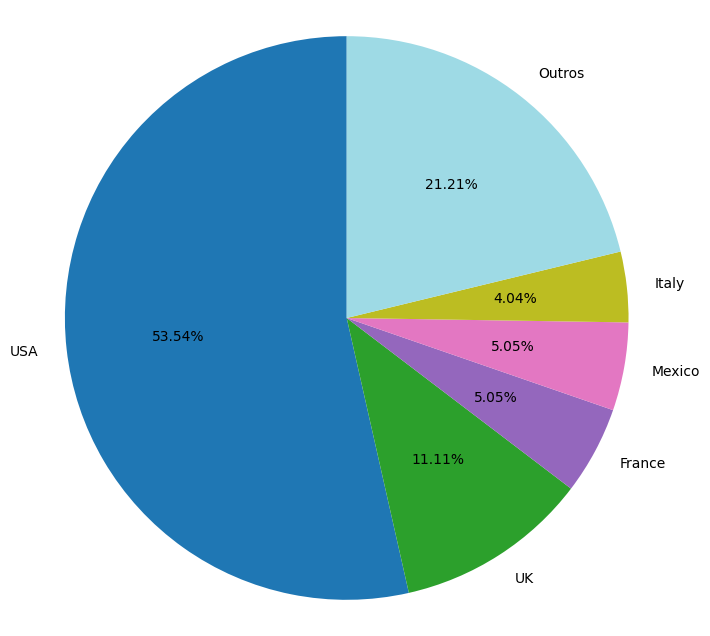

In [161]:
PizzaTopN(df_directign_country__winner_percentual, 5)

In [162]:
last_show_information(df_exploded_directing_winner, "Birth Country")

,Birth Country,LastYear,YearsWithout
0,Scotland,1932/33,92
1,Russian Empire,1929/30,95
2,USA,2024,0
3,Italy,1987,37
4,France,2011,13
5,Hungary,1943,81
6,Austria-Hungary,1960,64
7,Turkey,1954,70
8,Poland,1966,58
9,UK,2023,1


In [163]:
df_directign_continent_winner_count = DataFrameInfoTotalCount(df_exploded_directing_winner, "Birth Continent")
display(df_directign_continent_winner_count)

,count
Birth Continent,
North America,54
Europe,31
Asia,7
Central America,5
Oceania,2


In [164]:
df_directign_continent__winner_percentual = DataFrameInfoPercentual(df_exploded_directing_winner, "Birth Continent")
display(df_directign_continent__winner_percentual)

,Birth Continent,Percentual
0,North America,54.55
1,Europe,31.31
2,Asia,7.07
3,Central America,5.05
4,Oceania,2.02


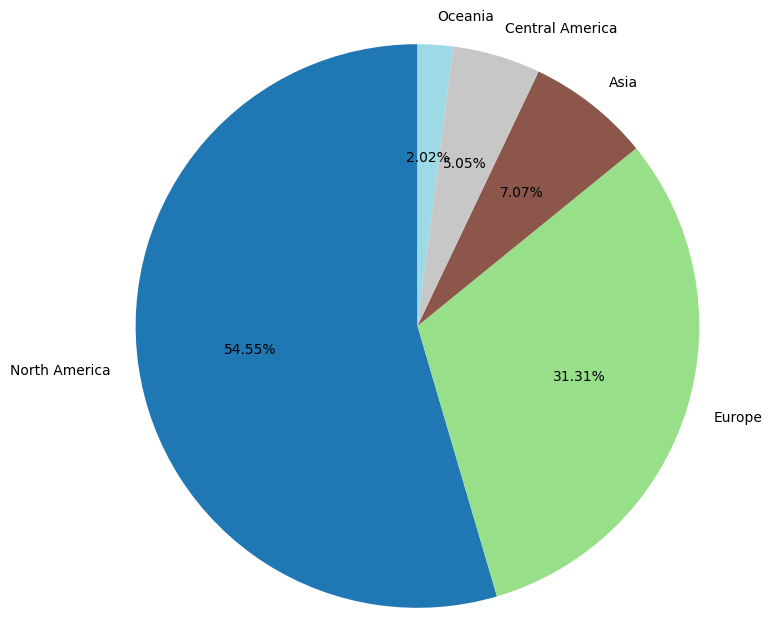

In [165]:
PizzaTopN(df_directign_continent__winner_percentual, 5)

#### Writting

##### Genero

###### Indicações

In [166]:
df_writting = df_Official.copy()
df_writting = df_writting[df_writting["CanonicalCategory"].isin(["WRITING (Adapted Screenplay)", "WRITING (Original Story)"])]
df_writting = df_writting[["CanonicalCategory", "Year", "Film", "Genre", "Nominees", "Winner"]]
display(df_writting)

,CanonicalCategory,Year,Film,Genre,Nominees,Winner
31,WRITING (Adapted Screenplay),1927/28,The Jazz Singer,Drama,Alfred Cohn,False
32,WRITING (Adapted Screenplay),1927/28,Glorious Betsy,Drama,Anthony Coldeway,False
33,WRITING (Adapted Screenplay),1927/28,7th Heaven,Drama,Benjamin Glazer,True
34,WRITING (Original Story),1927/28,The Last Command,Drama,Lajos Biro,False
35,WRITING (Original Story),1927/28,Underworld,Drama,Ben Hecht,True
...,...,...,...,...,...,...
11986,WRITING (Adapted Screenplay),2024,A Complete Unknown,Drama,"James Mangold, Jay Cocks",False
11987,WRITING (Adapted Screenplay),2024,Conclave,Drama,Peter Straughan,True
11988,WRITING (Adapted Screenplay),2024,Emilia Pérez,Drama,"Jacques Audiard, In collaboration with Thomas ...",False
11989,WRITING (Adapted Screenplay),2024,Nickel Boys,Drama,"RaMell Ross, Joslyn Barnes",False


In [167]:
DataFrameInfoTotalCount(df_writting, "Genre")

,count
Genre,
Drama,322
Comedy,103
Crime,41
Romance,24
Adventure,20
War,17
Thriller,17
Music,15
Western,12


In [168]:
df_writting_percentual = DataFrameInfoPercentual(df_writting, "Genre")
display(df_writting_percentual)

,Genre,Percentual
0,Drama,52.87
1,Comedy,16.91
2,Crime,6.73
3,Romance,3.94
4,Adventure,3.28
5,War,2.79
6,Thriller,2.79
7,Music,2.46
8,Western,1.97
9,Action,1.48


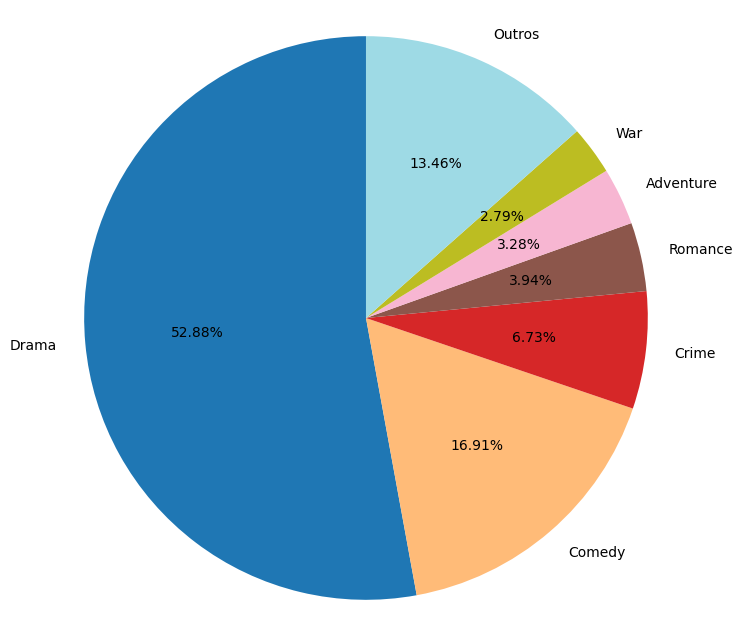

In [169]:
PizzaTopN(df_writting_percentual, 6)

In [170]:
df_writting_count = show_raw_data_count_for_year(df_writting, "Genre")
display(df_writting_count)

,Year,Genre,Count
0,1927/28,Action,0
1,1927/28,Adventure,0
2,1927/28,Animation,0
3,1927/28,Comedy,0
4,1927/28,Crime,0
...,...,...,...
1644,2024,Romance,0
1645,2024,Science Fiction,0
1646,2024,Thriller,0
1647,2024,War,0


In [171]:
df_writting_data_analytics = calculate_basics_analitics(df_writting_count, "Genre")
display(df_writting_data_analytics)

,Genre,Média,Mediana,Moda,Amplitude,Desvio
0,Action,0.09,0.0,[0],1,0.291636
1,Adventure,0.20,0.0,[0],3,0.519177
2,Animation,0.03,0.0,[0],1,0.174022
3,Comedy,1.06,1.0,[0],5,1.188613
4,Crime,0.42,0.0,[0],4,0.719303
5,Drama,3.31,3.0,[3],8,1.396024
6,Family,0.01,0.0,[0],1,0.101535
7,Fantasy,0.04,0.0,[0],1,0.199871
8,History,0.08,0.0,[0],1,0.276515
9,Horror,0.02,0.0,[0],1,0.142842


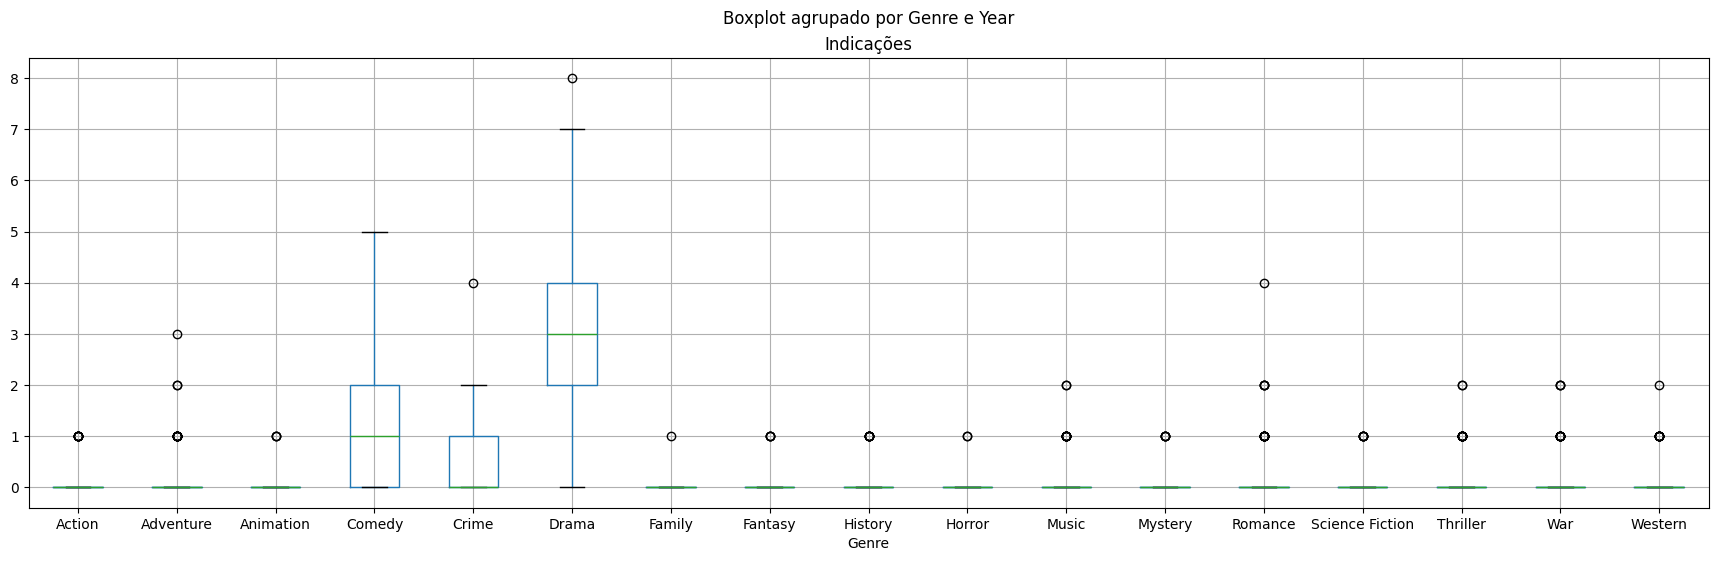

In [172]:
BoxplotByCollumForYears(df_writting, "Genre")

###### Vitórias na categoria

In [173]:
df_writting_winner = df_writting[df_writting["Winner"] == True]
display(df_writting_winner)


,CanonicalCategory,Year,Film,Genre,Nominees,Winner
33,WRITING (Adapted Screenplay),1927/28,7th Heaven,Drama,Benjamin Glazer,True
35,WRITING (Original Story),1927/28,Underworld,Drama,Ben Hecht,True
83,WRITING (Adapted Screenplay),1928/29,The Patriot,Drama,Hans Kraly,True
129,WRITING (Adapted Screenplay),1929/30,The Big House,Crime,Frances Marion,True
167,WRITING (Adapted Screenplay),1930/31,Cimarron,Western,Howard Estabrook,True
...,...,...,...,...,...,...
11468,WRITING (Adapted Screenplay),2020,The Father,Drama,"Christopher Hampton, Florian Zeller",True
11589,WRITING (Adapted Screenplay),2021,CODA,Drama,Siân Heder,True
11717,WRITING (Adapted Screenplay),2022,Women Talking,Drama,Sarah Polley,True
11846,WRITING (Adapted Screenplay),2023,American Fiction,Comedy,Cord Jefferson,True


In [174]:
DataFrameInfoTotalCount(df_writting_winner, "Genre")

,count
Genre,
Drama,72
Comedy,18
Crime,8
Adventure,5
Thriller,4
Romance,4
History,3
War,3
Music,2


In [175]:
df_writting_winner_genre_percentual = DataFrameInfoPercentual(df_writting_winner, "Genre")
display(df_writting_winner_genre_percentual)

,Genre,Percentual
0,Drama,58.06
1,Comedy,14.52
2,Crime,6.45
3,Adventure,4.03
4,Thriller,3.23
5,Romance,3.23
6,History,2.42
7,War,2.42
8,Music,1.61
9,Western,0.81


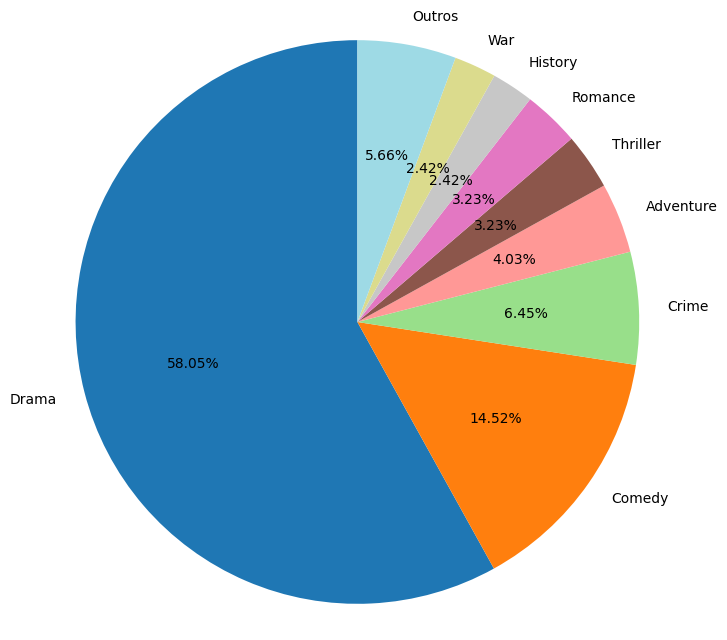

In [176]:
PizzaTopN(df_writting_winner_genre_percentual, 8)

In [177]:
last_show_information(df_writting_winner, "Genre")

,Genre,LastYear,YearsWithout
0,Drama,2024,0
1,Crime,2018,6
2,Western,1930/31,94
3,War,1953,71
4,Romance,2017,7
5,Comedy,2023,1
6,Music,1955,69
7,Thriller,2000,24
8,Adventure,2003,21
9,Animation,1951,73


##### País

###### Indicações

In [178]:
df_writting_country = df_Official.copy()
df_writting_country = df_writting_country[df_writting_country["CanonicalCategory"].isin(["WRITING (Adapted Screenplay)", "WRITING (Original Story)"])]
df_writting_country = df_writting_country[["CanonicalCategory", "Year","Film", "Name", "Birth Country", "Birth Continent",  "Winner"]]
display(df_writting_country)

,CanonicalCategory,Year,Film,Name,Birth Country,Birth Continent,Winner
31,WRITING (Adapted Screenplay),1927/28,The Jazz Singer,Alfred Cohn,[Denmark],[Europe],False
32,WRITING (Adapted Screenplay),1927/28,Glorious Betsy,Anthony Coldeway,[USA],[North America],False
33,WRITING (Adapted Screenplay),1927/28,7th Heaven,Benjamin Glazer,[UK],[Europe],True
34,WRITING (Original Story),1927/28,The Last Command,Lajos Biro,[Romania],[Europe],False
35,WRITING (Original Story),1927/28,Underworld,Ben Hecht,[USA],[North America],True
...,...,...,...,...,...,...,...
11986,WRITING (Adapted Screenplay),2024,A Complete Unknown,Screenplay by James Mangold and Jay Cocks,"[USA, USA]","[North America, North America]",False
11987,WRITING (Adapted Screenplay),2024,Conclave,Screenplay by Peter Straughan,[UK],[Europe],True
11988,WRITING (Adapted Screenplay),2024,Emilia Pérez,Screenplay by Jacques Audiard; In collaboratio...,"[France, France, France, France]","[Europe, Europe, Europe, Europe]",False
11989,WRITING (Adapted Screenplay),2024,Nickel Boys,Screenplay by RaMell Ross & Joslyn Barnes,"[Germany, USA]","[Europe, North America]",False


In [179]:
df_exploded_writting = df_writting_country.copy().explode(["Birth Country", "Birth Continent"])
display(df_exploded_writting)

,CanonicalCategory,Year,Film,Name,Birth Country,Birth Continent,Winner
31,WRITING (Adapted Screenplay),1927/28,The Jazz Singer,Alfred Cohn,Denmark,Europe,False
32,WRITING (Adapted Screenplay),1927/28,Glorious Betsy,Anthony Coldeway,USA,North America,False
33,WRITING (Adapted Screenplay),1927/28,7th Heaven,Benjamin Glazer,UK,Europe,True
34,WRITING (Original Story),1927/28,The Last Command,Lajos Biro,Romania,Europe,False
35,WRITING (Original Story),1927/28,Underworld,Ben Hecht,USA,North America,True
...,...,...,...,...,...,...,...
11989,WRITING (Adapted Screenplay),2024,Nickel Boys,Screenplay by RaMell Ross & Joslyn Barnes,Germany,Europe,False
11989,WRITING (Adapted Screenplay),2024,Nickel Boys,Screenplay by RaMell Ross & Joslyn Barnes,USA,North America,False
11990,WRITING (Adapted Screenplay),2024,Sing Sing,"Screenplay by Clint Bentley, Greg Kwedar; Stor...",USA,North America,False
11990,WRITING (Adapted Screenplay),2024,Sing Sing,"Screenplay by Clint Bentley, Greg Kwedar; Stor...",USA,North America,False


In [180]:
df_writting_country_count = DataFrameInfoTotalCount(df_exploded_writting, "Birth Country")
display(df_directign_country_count)

,count
Birth Country,
USA,253
UK,66
France,24
Italy,18
Canada,13
Germany,12
Austria-Hungary,10
Poland,9
Australia,8


In [181]:
df_writting_country_percentual = DataFrameInfoPercentual(df_exploded_writting, "Birth Country")
display(df_directign_country_percentual)

,Birth Country,Percentual
0,USA,52.60
1,UK,13.72
2,France,4.99
3,Italy,3.74
4,Canada,2.70
5,Germany,2.49
6,Austria-Hungary,2.08
7,Poland,1.87
8,Australia,1.66
9,Sweden,1.46


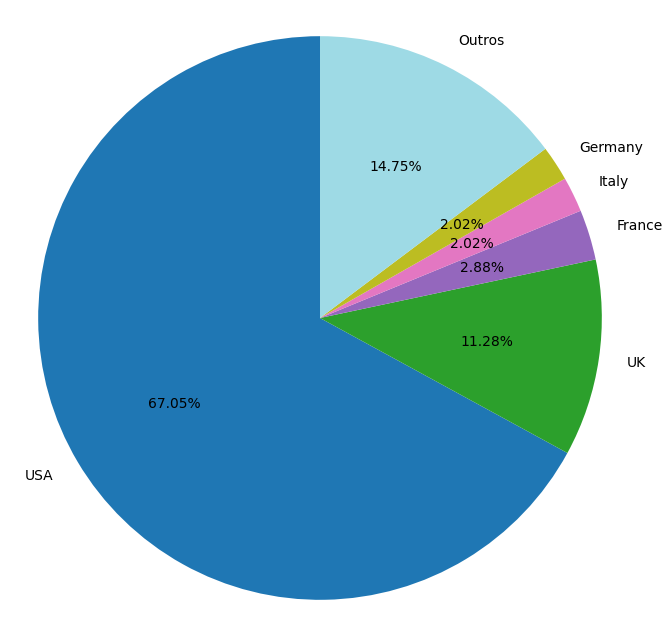

In [182]:
PizzaTopN(df_writting_country_percentual, 5)

In [183]:
df_writting_continent_count = DataFrameInfoTotalCount(df_exploded_writting, "Birth Continent")
display(df_writting_continent_count)

,count
Birth Continent,
North America,645
Europe,243
Oceania,20
Asia,14
Africa,8
Central America,3
South America,2


In [184]:
df_writting_continent_percentual = DataFrameInfoPercentual(df_exploded_writting, "Birth Continent")
display(df_writting_continent_percentual)

,Birth Continent,Percentual
0,North America,68.98
1,Europe,25.99
2,Oceania,2.14
3,Asia,1.50
4,Africa,0.86
5,Central America,0.32
6,South America,0.21


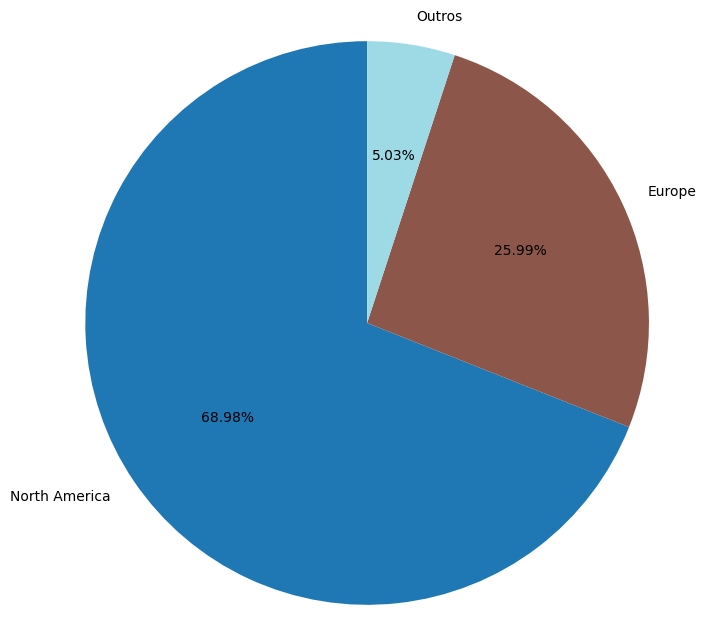

In [185]:
PizzaTopN(df_writting_continent_percentual, 2)

###### Vitórias na categoria

In [186]:
df_writting_country_winner = df_writting_country[df_writting_country["Winner"] == True]
display(df_writting_country_winner)

,CanonicalCategory,Year,Film,Name,Birth Country,Birth Continent,Winner
33,WRITING (Adapted Screenplay),1927/28,7th Heaven,Benjamin Glazer,[UK],[Europe],True
35,WRITING (Original Story),1927/28,Underworld,Ben Hecht,[USA],[North America],True
83,WRITING (Adapted Screenplay),1928/29,The Patriot,Hans Kraly,[Germany],[Europe],True
129,WRITING (Adapted Screenplay),1929/30,The Big House,Frances Marion,[USA],[North America],True
167,WRITING (Adapted Screenplay),1930/31,Cimarron,Howard Estabrook,[USA],[North America],True
...,...,...,...,...,...,...,...
11468,WRITING (Adapted Screenplay),2020,The Father,Screenplay by Christopher Hampton and Florian ...,"[Portugal, France]","[Europe, Europe]",True
11589,WRITING (Adapted Screenplay),2021,CODA,Screenplay by Siân Heder,[USA],[North America],True
11717,WRITING (Adapted Screenplay),2022,Women Talking,Screenplay by Sarah Polley,[Canada],[North America],True
11846,WRITING (Adapted Screenplay),2023,American Fiction,Written for the screen by Cord Jefferson,[USA],[North America],True


In [187]:
df_exploded_writting_winner = df_writting_country_winner.copy().explode(["Birth Country", "Birth Continent"])
display(df_exploded_writting_winner)

,CanonicalCategory,Year,Film,Name,Birth Country,Birth Continent,Winner
33,WRITING (Adapted Screenplay),1927/28,7th Heaven,Benjamin Glazer,UK,Europe,True
35,WRITING (Original Story),1927/28,Underworld,Ben Hecht,USA,North America,True
83,WRITING (Adapted Screenplay),1928/29,The Patriot,Hans Kraly,Germany,Europe,True
129,WRITING (Adapted Screenplay),1929/30,The Big House,Frances Marion,USA,North America,True
167,WRITING (Adapted Screenplay),1930/31,Cimarron,Howard Estabrook,USA,North America,True
...,...,...,...,...,...,...,...
11468,WRITING (Adapted Screenplay),2020,The Father,Screenplay by Christopher Hampton and Florian ...,France,Europe,True
11589,WRITING (Adapted Screenplay),2021,CODA,Screenplay by Siân Heder,USA,North America,True
11717,WRITING (Adapted Screenplay),2022,Women Talking,Screenplay by Sarah Polley,Canada,North America,True
11846,WRITING (Adapted Screenplay),2023,American Fiction,Written for the screen by Cord Jefferson,USA,North America,True


In [188]:
df_writting_country_winner_count = DataFrameInfoTotalCount(df_exploded_writting_winner, "Birth Country")
display(df_writting_country_winner_count)

,count
Birth Country,
USA,122
UK,20
Germany,4
New Zealand,4
Canada,3
France,2
Switzerland,2
South Africa,2
Hungary,2


In [189]:
df_writting_country__winner_percentual = DataFrameInfoPercentual(df_exploded_writting_winner, "Birth Country")
display(df_writting_country__winner_percentual)

,Birth Country,Percentual
0,USA,70.52
1,UK,11.56
2,Germany,2.31
3,New Zealand,2.31
4,Canada,1.73
5,France,1.16
6,Switzerland,1.16
7,South Africa,1.16
8,Hungary,1.16
9,Portugal,1.16


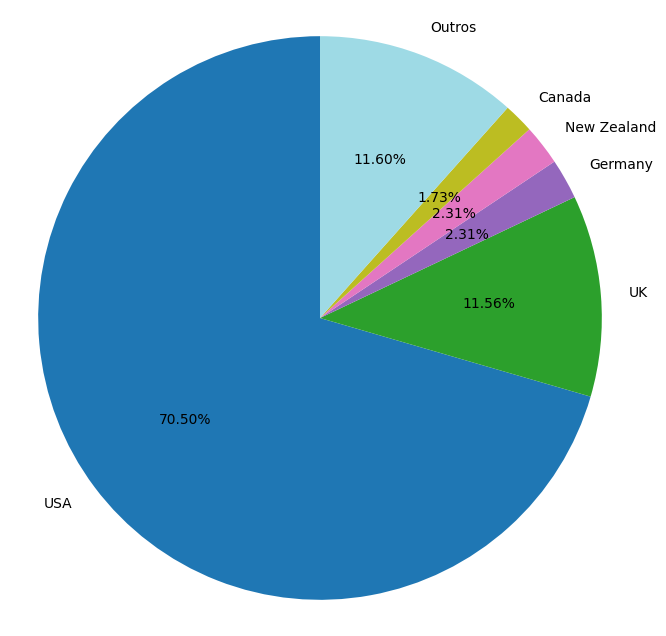

In [190]:
PizzaTopN(df_writting_country__winner_percentual, 5)

In [191]:
last_show_information(df_exploded_writting_winner, "Birth Country")

,Birth Country,LastYear,YearsWithout
0,UK,2024,0
1,USA,2023,1
2,Germany,1992,32
3,Romania,1934,90
4,Canada,2022,2
5,Hungria,1937,87
6,Ireland,1938,86
7,South Africa,2002,22
8,Hungary,1942,82
9,Austria,1942,82


In [192]:
df_writting_continent_winner_count = DataFrameInfoTotalCount(df_exploded_writting_winner, "Birth Continent")
display(df_writting_continent_winner_count)

,count
Birth Continent,
North America,125
Europe,38
Oceania,5
Africa,3
Asia,1


In [193]:
df_writting_continent__winner_percentual = DataFrameInfoPercentual(df_exploded_writting_winner, "Birth Continent")
display(df_writting_continent__winner_percentual)

,Birth Continent,Percentual
0,North America,72.67
1,Europe,22.09
2,Oceania,2.91
3,Africa,1.74
4,Asia,0.58


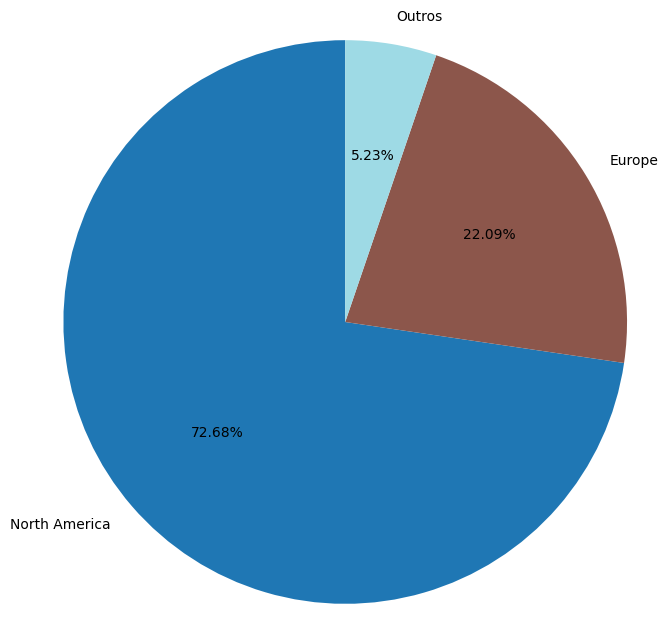

In [194]:
PizzaTopN(df_writting_continent__winner_percentual, 2)